In [70]:
import h5py
import numpy as np
import math
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma

# ---------------------------------------------------------
# 1. Helpers & Statistics
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    if err <= 0: return f"{mean}"
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
    else:
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1)) 
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"

def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
    return fitted_params

# ---------------------------------------------------------
# 2. Extrapolation Routine for Parameters
# ---------------------------------------------------------
def fit_param_linear(inv_zeta_vals, param_jk_samples):
    """
    Fits y = c0 + c1 * (1/zeta_hat) for a given parameter.
    """
    N_PL, N_JK = param_jk_samples.shape

    mean_y = np.mean(param_jk_samples, axis=1)
    cov_y = np.cov(param_jk_samples, bias=True) * (N_JK - 1)

    try:
        y_gvar = gv.gvar(mean_y, cov_y)
    except Exception:
        y_gvar = gv.gvar(mean_y, np.sqrt(np.diag(cov_y)))

    # Linear fit in 1/zeta_hat
    def fcn(x, p):
        return p['c0'] + p['c1'] * x**2

    prior = {'c0': gv.gvar(0, 5000000), 'c1': gv.gvar(0, 5000000)}

    # Central fit for chi2/dof
    #fit_mean = lsqfit.nonlinear_fit(data=(inv_zeta_vals, y_gvar), fcn=fcn, prior=prior)
    #chi2_dof = fit_mean.chi2 / fit_mean.dof if fit_mean.dof > 0 else 0.0
    
    # Store central line for plotting
    #c0_central = fit_mean.pmean['c0']
    #c1_central = fit_mean.pmean['c1']

    # JK fits
    c0_jk = []
    c1_jk = []
    chi2_dof = []
    cov_y_eval = gv.evalcov(y_gvar)

    for k in range(N_JK):
        y_k_gvar = gv.gvar(param_jk_samples[:, k], cov_y_eval)
        fit_k = lsqfit.nonlinear_fit(data=(inv_zeta_vals, y_k_gvar), fcn=fcn, prior=prior)
        chi2_dof.append(fit_k.chi2 / fit_k.dof)
        c0_jk.append(fit_k.pmean['c0'])
        c1_jk.append(fit_k.pmean['c1'])

    return np.array(c0_jk), np.array(c1_jk), np.array(chi2_dof)

# ---------------------------------------------------------
# 3. Main Routine
# ---------------------------------------------------------
def parameter_extrapolation_and_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=1000):
    
    MassN = 0.6228
    lata = 0.11403
    massterm = MassN * (197 * 0.001 / lata)
    
    pl_to_zeta = {
        -4: 0.785756,
        -3: 0.539684,
        -2: 0.294367,
        -1: 0.090772
    }
    
    inv_zeta_vals = np.array([1.0 / pl_to_zeta[pl] for pl in PL_list])
    sort_idx = np.argsort(inv_zeta_vals)
    inv_zeta_vals = inv_zeta_vals[sort_idx]
    sorted_PL_list = [PL_list[i] for i in sort_idx]
    N_PL = len(sorted_PL_list)
    
    # Create dynamic PL string for filenames (e.g. [-2, -3, -4] -> "234")
    pl_str = "".join([str(abs(p)) for p in sorted(PL_list, reverse=True)])
    
    # Load Initial Data to get N_JK
    init_filename = f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{sorted_PL_list[0]}.h5"
    init_params = load_params_from_h5(init_filename)
    N_JK = len(init_params['a_re'])

    # Dictionary to hold the scaled parameters for all PLs
    param_names = ['a_re', 'c_re', 'j_re', 'd_re', 
                   'a_im', 'c_im', 'j_im', 'd_im', 
                   'a_reA12B', 'c_reA12B', 'j_reA12B', 'd_reA12B']
                   
    raw_data = {p: np.zeros((N_PL, N_JK)) for p in param_names}

    print("[1] Loading and Scaling Parameters...")
    for i, pl in enumerate(sorted_PL_list):
        filename = f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
        params = load_params_from_h5(filename)
        
        # Apply scaling rules
        raw_data['a_re'][i, :] = params['a_re']
        raw_data['c_re'][i, :] = params['c_re'] / (pl**2)
        raw_data['j_re'][i, :] = params['j_re']
        raw_data['d_re'][i, :] = params['d_re']
        
        raw_data['a_im'][i, :] = params['a_im'] / pl
        raw_data['c_im'][i, :] = params['c_im'] / (pl**2)
        raw_data['j_im'][i, :] = params['j_im']
        raw_data['d_im'][i, :] = params['d_im']
        
        raw_data['a_reA12B'][i, :] = -params['a_reA12B']
        raw_data['c_reA12B'][i, :] = params['c_reA12B'] / (pl**2)
        raw_data['j_reA12B'][i, :] = params['j_reA12B']
        raw_data['d_reA12B'][i, :] = params['d_reA12B']

    print("[2] Extrapolating Parameters to 1/zeta_hat -> 0...")
    extrapolated_jk = {}
    
    # Plotting setup for parameters
    fig_p, axes_p = plt.subplots(3, 4, figsize=(18, 12))
    axes_p = axes_p.flatten()
    plot_x = np.linspace(0, max(inv_zeta_vals)*1.1, 50)

    for idx, p_name in enumerate(param_names):
        jk_samples = raw_data[p_name]
        
        # Fit
        c0_jk, c1_jk, chi2 = fit_param_linear(inv_zeta_vals, jk_samples)
        extrapolated_jk[p_name] = c0_jk
        
        # Get means and errors for the raw data points
        y_means = np.mean(jk_samples, axis=1)
        y_errs = [Jackknife(jk_samples[i, :])[1] for i in range(N_PL)]
        
        # Generate Error Band for the fit line
        fit_m = np.zeros(len(plot_x))
        fit_e = np.zeros(len(plot_x))
        for i_x, px in enumerate(plot_x):
            # Evaluate the linear fit at this x for all JK samples
            jk_vals_at_x = c0_jk + c1_jk * px**2
            fit_m[i_x], fit_e[i_x] = Jackknife(jk_vals_at_x)
        
        c0_m, c0_e = Jackknife(c0_jk)
        
        # Plot
        ax = axes_p[idx]
        ax.errorbar(inv_zeta_vals, y_means, yerr=y_errs, fmt='o', color='black', label='Data')
        ax.plot(plot_x, fit_m, color='red', linestyle='--', label='Fit')
        ax.fill_between(plot_x, fit_m - fit_e, fit_m + fit_e, color='red', alpha=0.3)
        ax.errorbar([0], [c0_m], yerr=[c0_e], fmt='s', color='blue', label='Extrap (x=0)')
        
        ax.set_title(f"{p_name}\n$\\chi^2/dof = {fmt_err(*Jackknife(chi2))}$")
        ax.set_xlabel("$1/\\hat{\\zeta}$")
        ax.grid(True, linestyle='--', alpha=0.5)
        if idx == 0: ax.legend()

    plt.tight_layout()
    plt.savefig(f"Param_Extrapolations_1byZetahat_sq_P{pl_str}_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf")
    plt.show()

    print("[3] Reconstructing Infinite-Momentum Amplitudes and Sivers Shift...")
    x_vals = np.linspace(-1, 1, num_points_x)
    
    # Pre-allocate arrays for all plot lines
    siv_m, siv_e = np.zeros(num_points_x), np.zeros(num_points_x)
    xsiv_m, xsiv_e = np.zeros(num_points_x), np.zeros(num_points_x)
    
    reA2B_m, reA2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    imA2B_m, imA2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    A2B_m, A2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    reA12B_m, reA12B_e = np.zeros(num_points_x), np.zeros(num_points_x)

    for j, x in enumerate(tqdm(x_vals, desc="Evaluating x slices")):
        abs_x = max(np.abs(x), 1e-12)
        safe_x = x if x != 0 else 1e-12
        
        # Slices to hold JK samples for this specific x
        siv_jk_slice = np.zeros(N_JK)
        reA2B_jk_slice = np.zeros(N_JK)
        imA2B_jk_slice = np.zeros(N_JK)
        A2B_jk_slice = np.zeros(N_JK)
        reA12B_jk_slice = np.zeros(N_JK)
        
        for k in range(N_JK):
            # Extract the extrapolated parameters for this specific JK sample
            a_R, c_R, d_R, j_R = extrapolated_jk['a_re'][k], extrapolated_jk['c_re'][k], 1.0 + extrapolated_jk['d_re'][k] * b2, extrapolated_jk['j_re'][k]
            a_I, c_I, d_I, j_I = extrapolated_jk['a_im'][k], extrapolated_jk['c_im'][k], 1.0 + extrapolated_jk['d_im'][k] * b2, extrapolated_jk['j_im'][k]
            a_A, c_A, d_A, j_A = extrapolated_jk['a_reA12B'][k], extrapolated_jk['c_reA12B'][k], 1.0 + extrapolated_jk['d_reA12B'][k] * b2, extrapolated_jk['j_reA12B'][k]

            # ReA2B
            cd_R = c_R / d_R # Safeguard
            term1_R = (2**(1 - j_R) * a_R * cd_R**(-0.25 - j_R/2) * d_R**(-j_R)) / gamma(j_R)
            re_eval = term1_R * (abs_x**(-0.5 + j_R)) * kv(0.5 - j_R, abs_x / np.sqrt(cd_R))

            # ImA2B
            cd_I = c_I / d_I # Safeguard
            term1_I = (2**(1 - j_I) * a_I * cd_I**(0.25 * (-3 - 2*j_I)) * d_I**(-j_I)) / gamma(j_I)
            im_eval = term1_I * (safe_x * abs_x**(-1.5 + j_I)) * kv(1.5 - j_I, np.sqrt(d_I / c_I) * abs_x)

            # ReA12B
            cd_A = c_A / d_A # Safeguard
            term1_A = (2**(1 - j_A) * a_A * cd_A**(-0.25 - j_A/2) * d_A**(-j_A)) / gamma(j_A)
            reA12B_eval = term1_A * (abs_x**(-0.5 + j_A)) * kv(0.5 - j_A, abs_x / np.sqrt(cd_A))

            # Store exact values into JK slices
            reA2B_jk_slice[k] = re_eval
            imA2B_jk_slice[k] = im_eval
            reA12B_jk_slice[k] = -2*reA12B_eval
            A2B_jk_slice[k] = 2*(re_eval - im_eval)
            siv_jk_slice[k] = (-massterm * reA12B_eval) / (re_eval - im_eval)

        # Jackknife the final reconstructed arrays to get standard means and errors
        siv_m[j], siv_e[j] = Jackknife(siv_jk_slice)
        xsiv_m[j], xsiv_e[j] = Jackknife(x * siv_jk_slice)
        
        reA2B_m[j], reA2B_e[j] = Jackknife(reA2B_jk_slice)
        imA2B_m[j], imA2B_e[j] = Jackknife(imA2B_jk_slice)
        reA12B_m[j], reA12B_e[j] = Jackknife(reA12B_jk_slice)
        A2B_m[j], A2B_e[j] = Jackknife(A2B_jk_slice)

    # ---------------------------------------------------------
    # 4. Final Plotting (6 Panel Layout)
    # ---------------------------------------------------------
    print("[4] Generating Final Plots...")
    fig_s, axes_s = plt.subplots(2, 3, figsize=(14, 8))
    ax1, ax2, ax3, ax4, ax5, ax6 = axes_s.flatten()

    # Real Plot
    ax1.plot(x_vals, reA2B_m, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, reA2B_m - reA2B_e, reA2B_m + reA2B_e, color='blue', alpha=0.3)
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}^2$]')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, imA2B_m, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, imA2B_m - imA2B_e, imA2B_m + imA2B_e, color='red', alpha=0.3) 
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}^2$]')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Full f1 Plot
    ax3.plot(x_vals, A2B_m, color='purple', label='A2B Mean')
    ax3.fill_between(x_vals, A2B_m - A2B_e, A2B_m + A2B_e, color='purple', alpha=0.3)
    ax3.set_title(f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}^2$]')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{f}}_{{1}}^{{(0)}}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    # A12B Plot
    ax4.plot(x_vals, reA12B_m, color='green')
    ax4.fill_between(x_vals, reA12B_m - reA12B_e, reA12B_m + reA12B_e, color='green', alpha=0.3)
    ax4.set_title(f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}^2$]')
    ax4.set_xlabel('$x$')
    ax4.set_ylabel('$\\tilde{{f}}_{{1}}^{{\\perp(1)}}$')
    ax4.grid(True, linestyle='--', alpha=0.6)

    # Sivers Shift Plot
    mask = x_vals >= 0
    ax5.plot(x_vals[mask], siv_m[mask], color='olive', linewidth=2)
    ax5.fill_between(x_vals[mask], siv_m[mask] - siv_e[mask], siv_m[mask] + siv_e[mask], color='olive', alpha=0.3)
    ax5.set_title(f'Sivers Shift $\\langle k_{{y}} \\rangle_{{TU}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}^2$]', fontsize=14)
    ax5.set_xlabel('$x$', fontsize=12)
    ax5.set_ylabel('$\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    ax5.grid(True, linestyle='--', alpha=0.6)

    # x * Sivers Shift Plot
    ax6.plot(x_vals[mask], xsiv_m[mask], color='olive', linewidth=2)
    ax6.fill_between(x_vals[mask], xsiv_m[mask] - xsiv_e[mask], xsiv_m[mask] + xsiv_e[mask], color='olive', alpha=0.3)
    ax6.set_title(f'$x *$ Sivers Shift ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}^2$]', fontsize=14)
    ax6.set_xlabel('$x$', fontsize=12)
    ax6.set_ylabel('$x\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    ax6.grid(True, linestyle='--', alpha=0.6)
    ax6.set_ylim(0, 0.04)

    plt.tight_layout()
    file_name = f"Extrapolated_AmpLevel_P{pl_str}_Sivers_1_over_zetahat_sq_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()



[1] Loading and Scaling Parameters...
[2] Extrapolating Parameters to 1/zeta_hat -> 0...


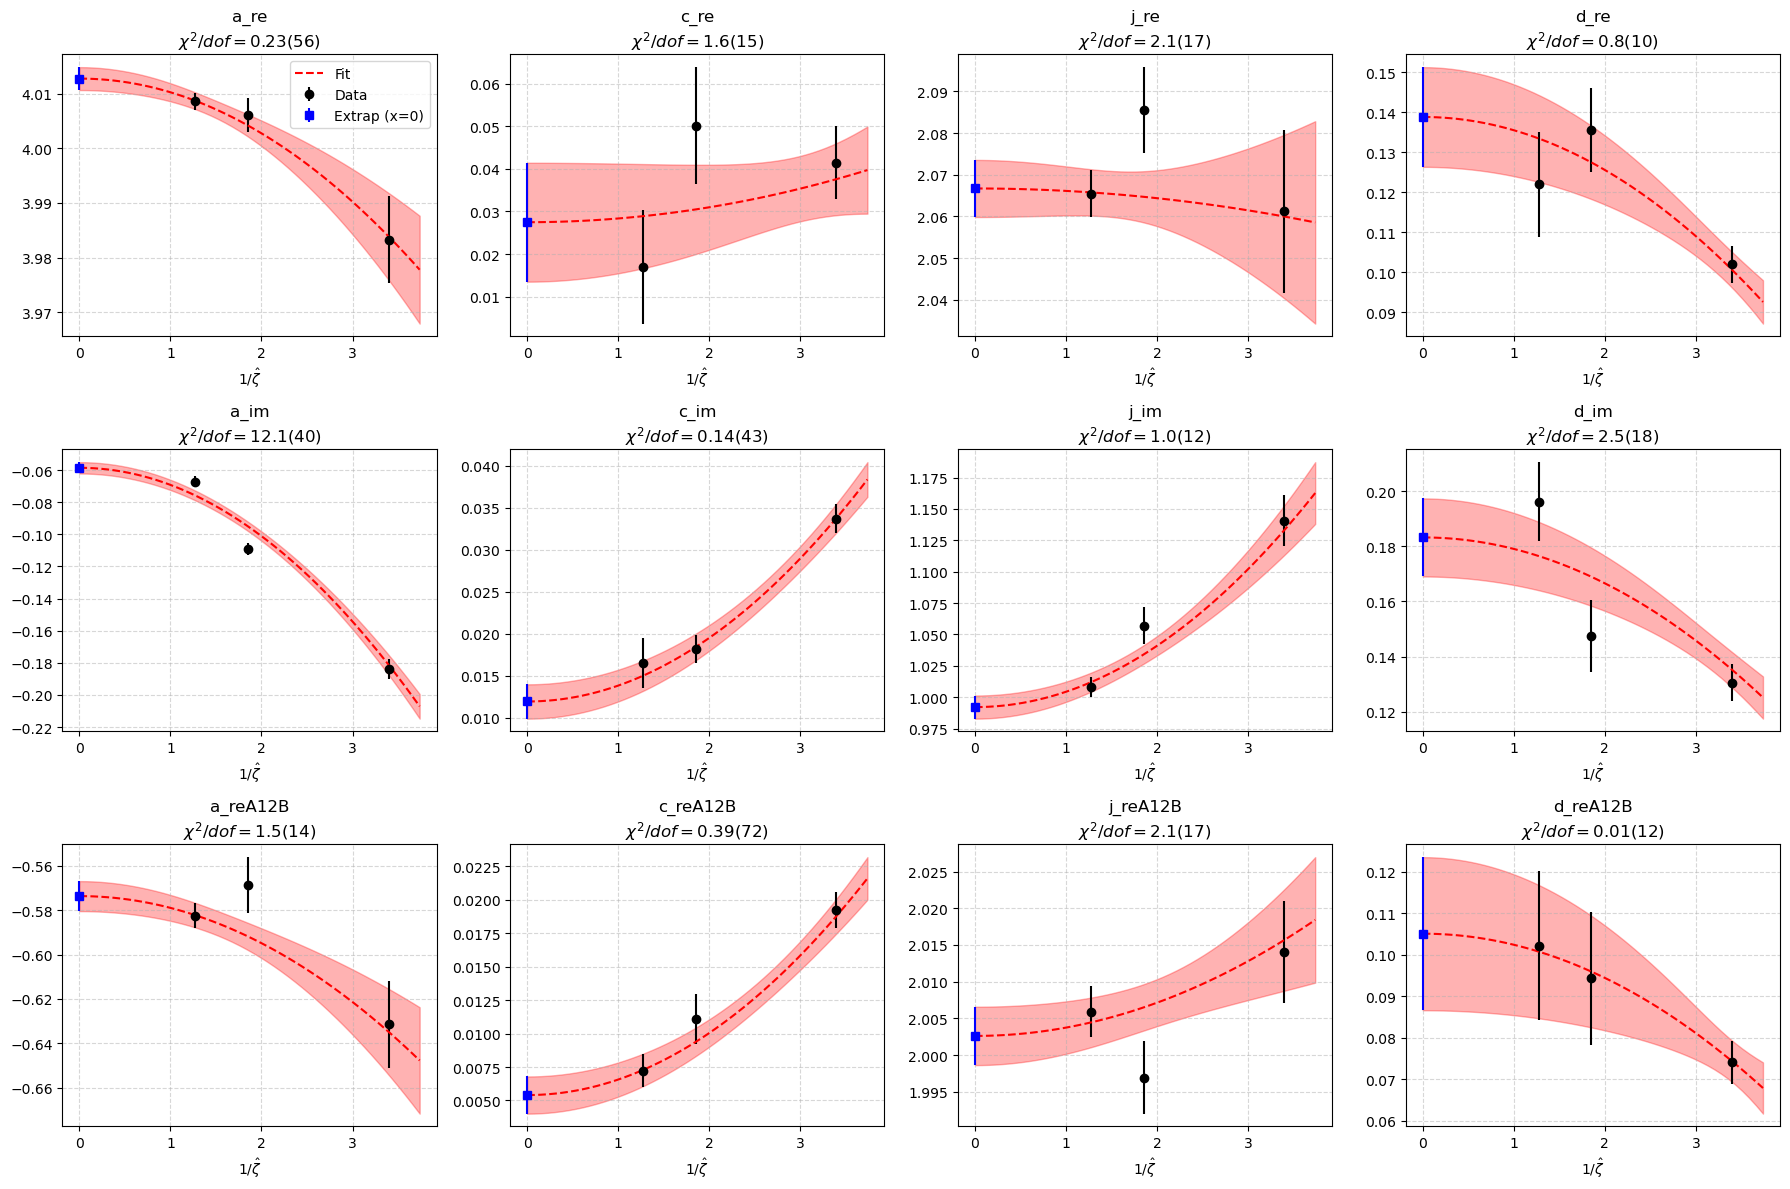

[3] Reconstructing Infinite-Momentum Amplitudes and Sivers Shift...


Evaluating x slices:   0%|          | 0/200 [00:00<?, ?it/s]

[4] Generating Final Plots...


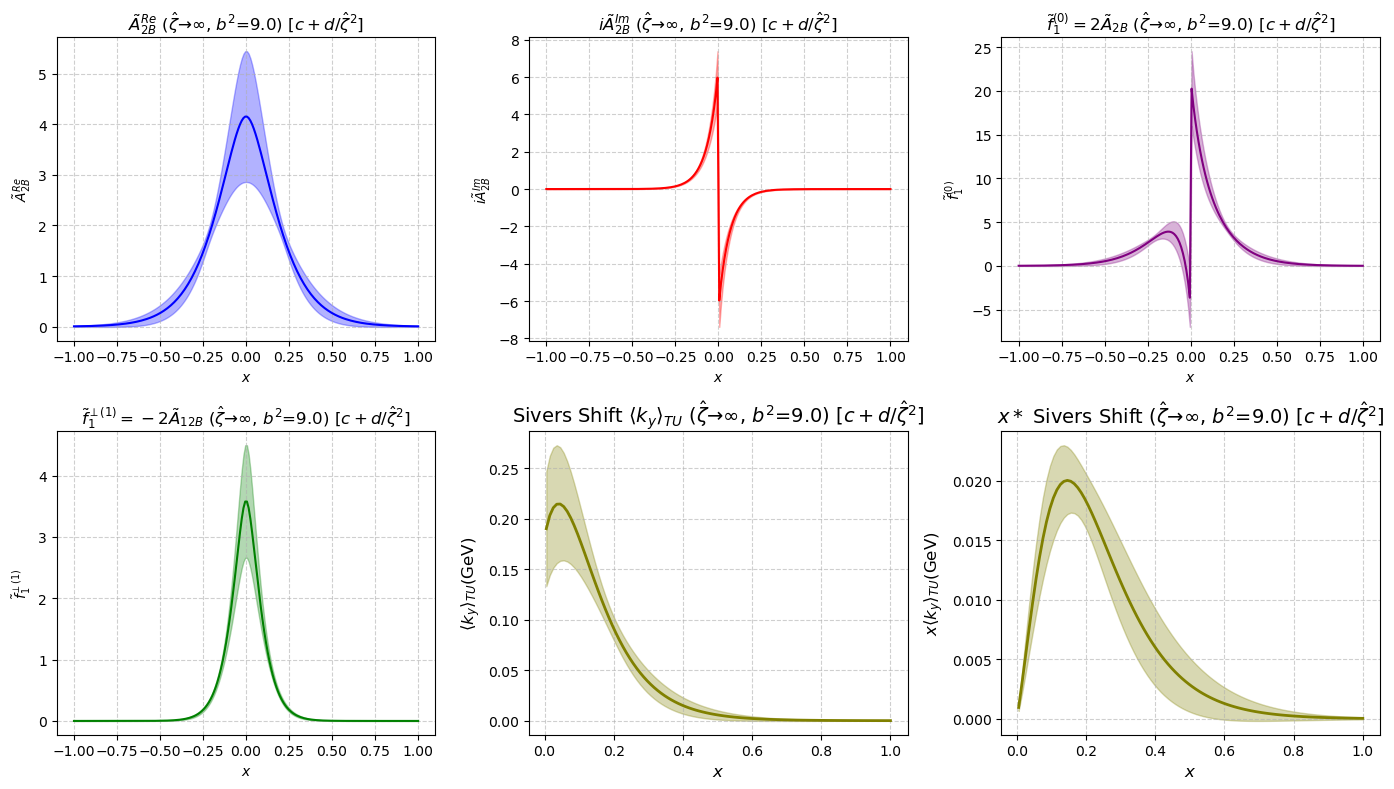

In [50]:
if __name__ == "__main__":
    PL_list = [-2, -3, -4]
    
    bminfit = 3
    etamin = 6
    etamax = 10
    
    parameter_extrapolation_and_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=200)

[1] Loading and Scaling Parameters...
[2] Extrapolating Parameters to 1/zeta_hat -> 0...


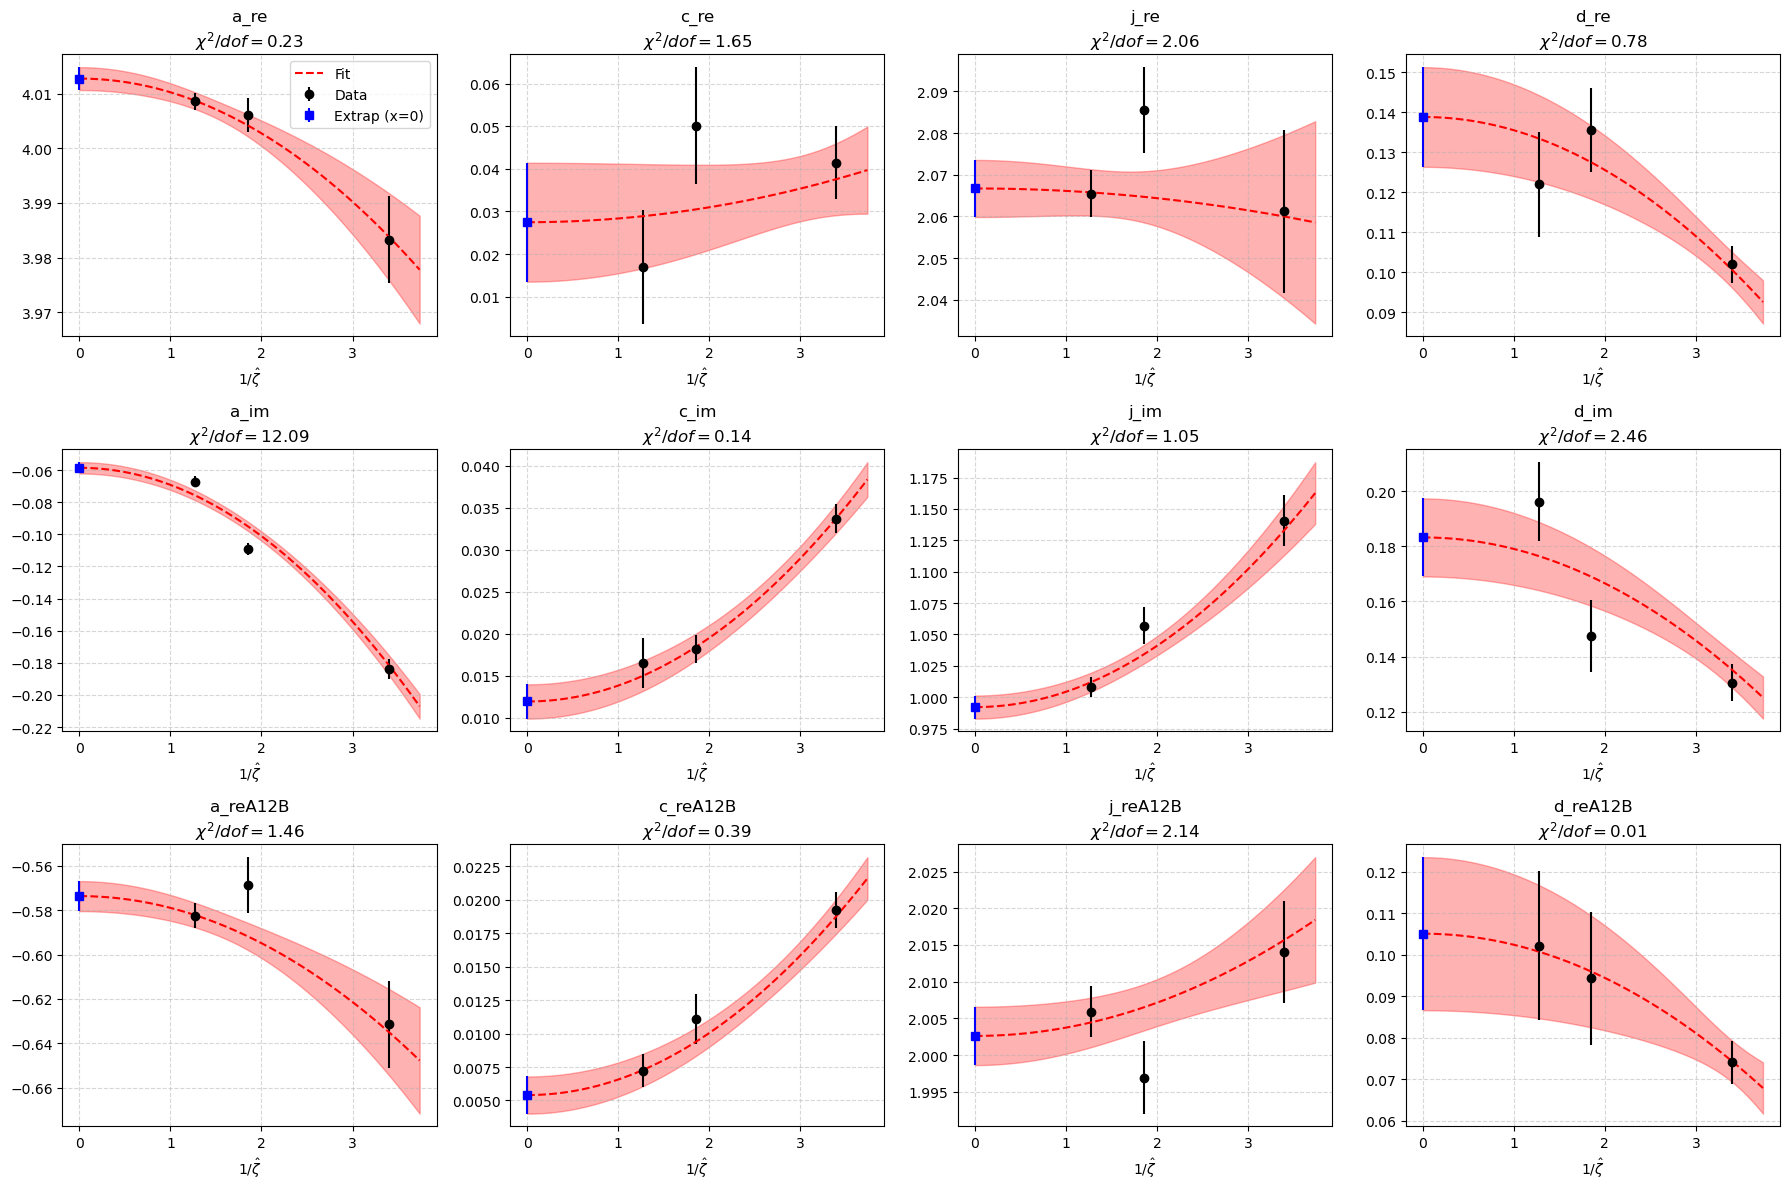

[3] Reconstructing Infinite-Momentum Amplitudes and Sivers Shift...


Evaluating x slices:   0%|          | 0/200 [00:00<?, ?it/s]

[4] Generating Final Plots...


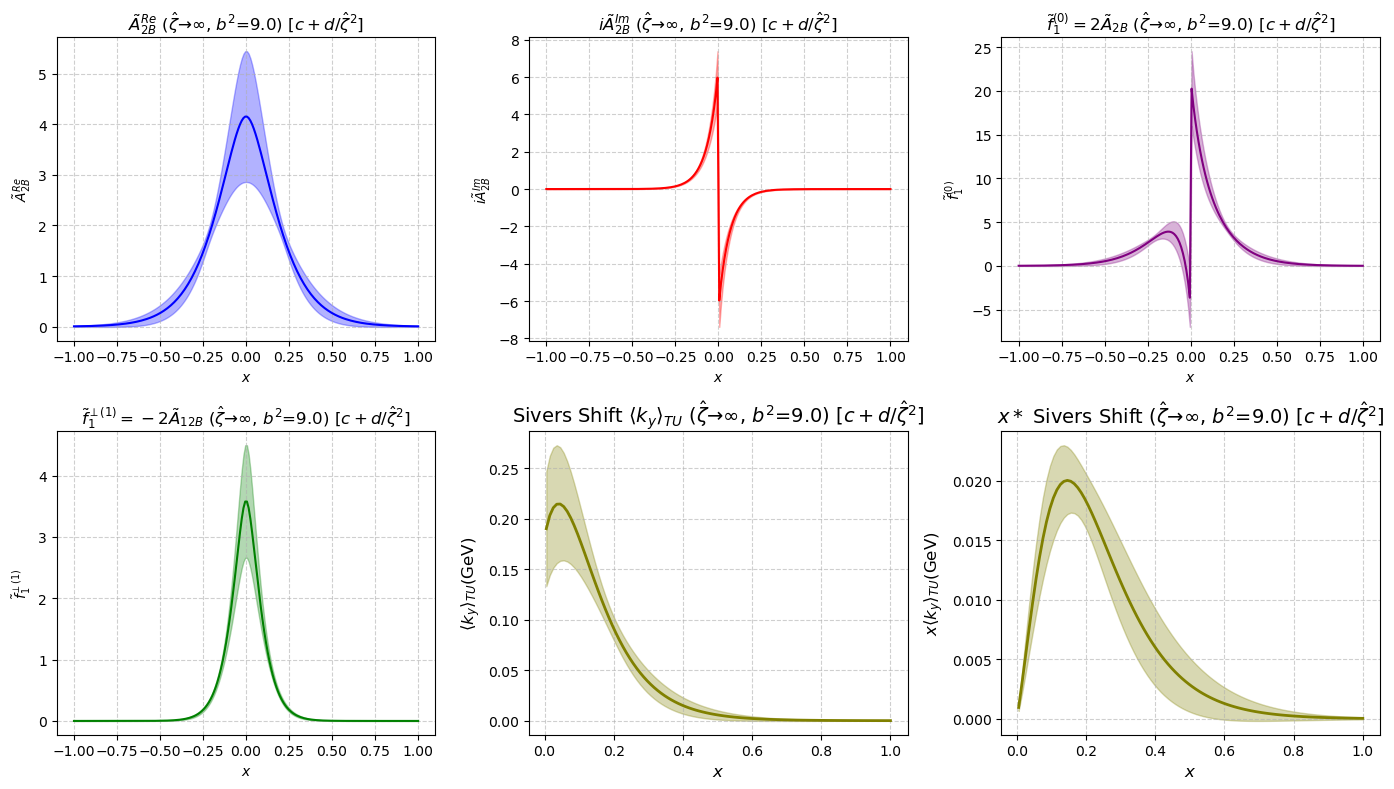

In [16]:
if __name__ == "__main__":
    PL_list = [-2, -3, -4]
    
    bminfit = 3
    etamin = 6
    etamax = 10
    
    parameter_extrapolation_and_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=200)

[1] Loading and Scaling Parameters...
[2] Extrapolating Parameters to 1/zeta_hat -> 0...


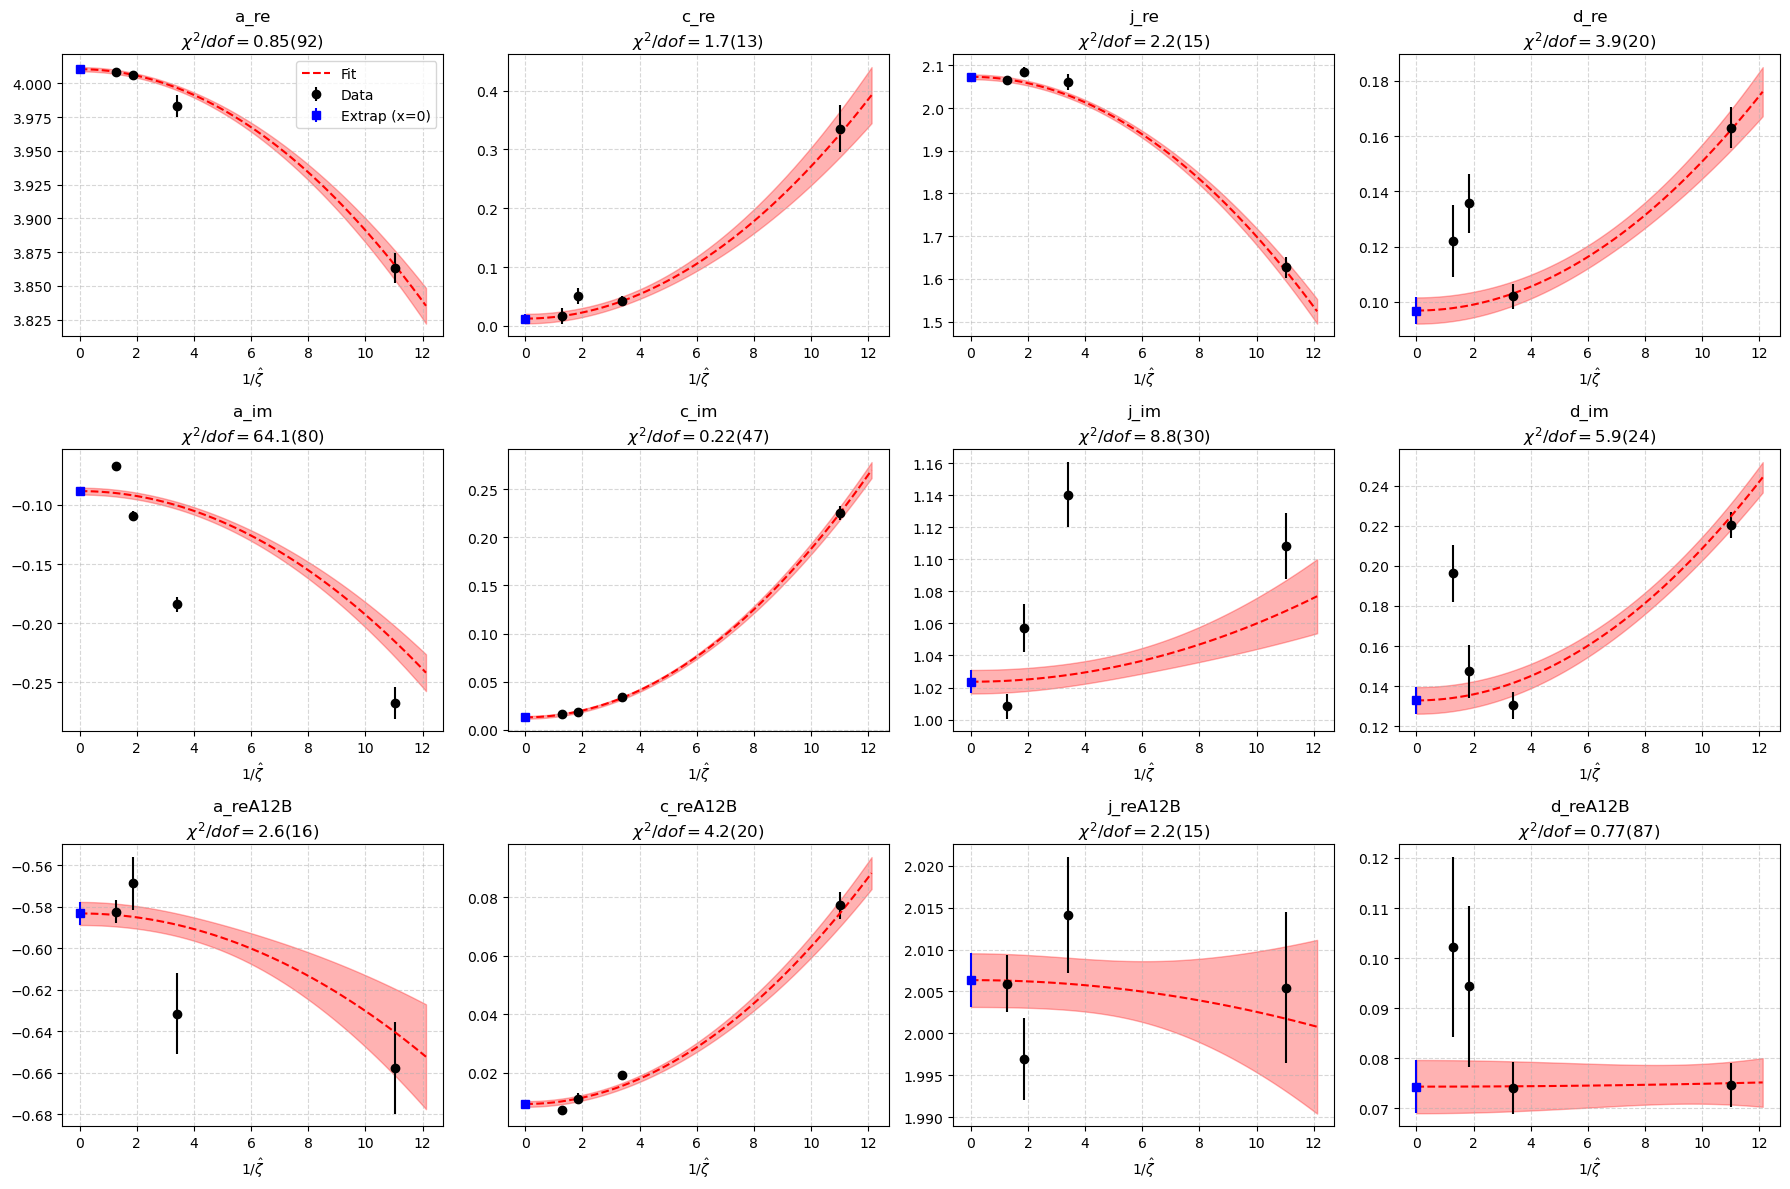

[3] Reconstructing Infinite-Momentum Amplitudes and Sivers Shift...


Evaluating x slices:   0%|          | 0/200 [00:00<?, ?it/s]

[4] Generating Final Plots...


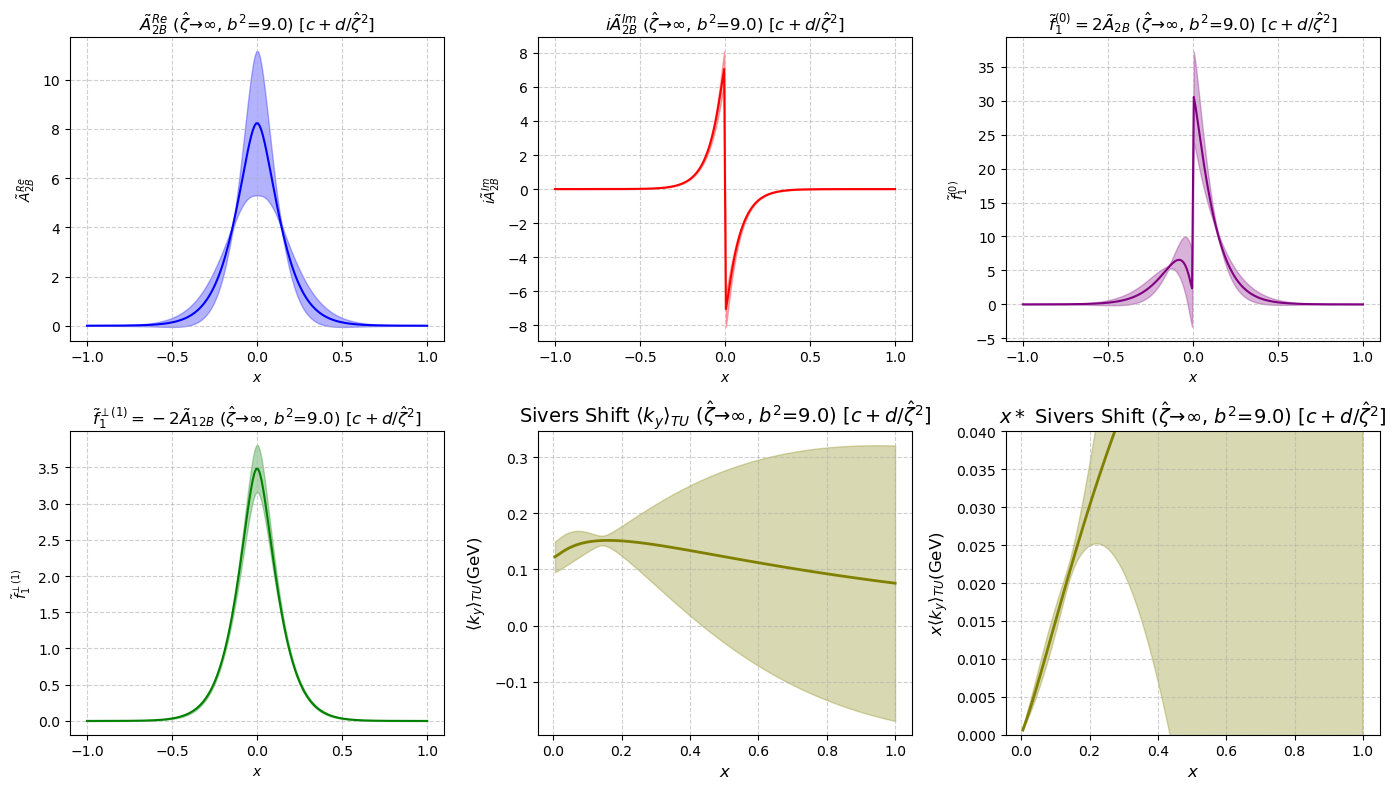

In [72]:
if __name__ == "__main__":
    PL_list = [-1, -2, -3, -4]
    
    bminfit = 3
    etamin = 6
    etamax = 10
    
    parameter_extrapolation_and_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=200)

In [52]:
import h5py
import numpy as np
import math
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma

# ---------------------------------------------------------
# 1. Helpers & Statistics
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    if err <= 0: return f"{mean}"
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
    else:
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1)) 
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"

def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
    return fitted_params

# ---------------------------------------------------------
# 2. Extrapolation Routine for Parameters
# ---------------------------------------------------------
def fit_param_linear(inv_zeta_vals, param_jk_samples):
    """
    Fits y = c0 + c1 * (1/zeta_hat) for a given parameter.
    """
    N_PL, N_JK = param_jk_samples.shape

    mean_y = np.mean(param_jk_samples, axis=1)
    cov_y = np.cov(param_jk_samples, bias=True) * (N_JK - 1)

    try:
        y_gvar = gv.gvar(mean_y, cov_y)
    except Exception:
        y_gvar = gv.gvar(mean_y, np.sqrt(np.diag(cov_y)))

    # Linear fit in 1/zeta_hat
    def fcn(x, p):
        return p['c0'] + p['c1'] * x**2 + p['c2'] * x**4

    prior = {'c0': gv.gvar(0, 5000000), 'c1': gv.gvar(0, 5000000), 'c2': gv.gvar(0, 5000000)}

    # Central fit for chi2/dof
    fit_mean = lsqfit.nonlinear_fit(data=(inv_zeta_vals, y_gvar), fcn=fcn, prior=prior, svdcut=1e-4)
    chi2_dof = fit_mean.chi2 / fit_mean.dof if fit_mean.dof > 0 else 0.0
    
    # Store central line for plotting
    c0_central = fit_mean.pmean['c0']
    c1_central = fit_mean.pmean['c1']
    c2_central = fit_mean.pmean['c2']

    # JK fits
    c0_jk = []
    c1_jk = []
    c2_jk = []
    cov_y_eval = gv.evalcov(y_gvar)

    for k in range(N_JK):
        y_k_gvar = gv.gvar(param_jk_samples[:, k], cov_y_eval)
        fit_k = lsqfit.nonlinear_fit(data=(inv_zeta_vals, y_k_gvar), fcn=fcn, prior=prior, svdcut=1e-4)
        c0_jk.append(fit_k.pmean['c0'])
        c1_jk.append(fit_k.pmean['c1'])
        c2_jk.append(fit_k.pmean['c2'])

    return np.array(c0_jk), np.array(c1_jk), np.array(c2_jk), chi2_dof, c0_central, c1_central, c2_central

# ---------------------------------------------------------
# 3. Main Routine
# ---------------------------------------------------------
def parameter_extrapolation_and_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=1000):
    
    MassN = 0.6228
    lata = 0.11403
    massterm = MassN * (197 * 0.001 / lata)
    
    pl_to_zeta = {
        -4: 0.785756,
        -3: 0.539684,
        -2: 0.294367,
        -1: 0.090772
    }
    
    inv_zeta_vals = np.array([1.0 / pl_to_zeta[pl] for pl in PL_list])
    sort_idx = np.argsort(inv_zeta_vals)
    inv_zeta_vals = inv_zeta_vals[sort_idx]
    sorted_PL_list = [PL_list[i] for i in sort_idx]
    N_PL = len(sorted_PL_list)
    
    # Create dynamic PL string for filenames (e.g. [-2, -3, -4] -> "234")
    pl_str = "".join([str(abs(p)) for p in sorted(PL_list, reverse=True)])
    
    # Load Initial Data to get N_JK
    init_filename = f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{sorted_PL_list[0]}.h5"
    init_params = load_params_from_h5(init_filename)
    N_JK = len(init_params['a_re'])

    # Dictionary to hold the scaled parameters for all PLs
    param_names = ['a_re', 'c_re', 'j_re', 'd_re', 
                   'a_im', 'c_im', 'j_im', 'd_im', 
                   'a_reA12B', 'c_reA12B', 'j_reA12B', 'd_reA12B']
                   
    raw_data = {p: np.zeros((N_PL, N_JK)) for p in param_names}

    print("[1] Loading and Scaling Parameters...")
    for i, pl in enumerate(sorted_PL_list):
        filename = f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
        params = load_params_from_h5(filename)
        
        # Apply scaling rules
        raw_data['a_re'][i, :] = params['a_re']
        raw_data['c_re'][i, :] = params['c_re'] / (pl**2)
        raw_data['j_re'][i, :] = params['j_re']
        raw_data['d_re'][i, :] = params['d_re']
        
        raw_data['a_im'][i, :] = params['a_im'] / pl
        raw_data['c_im'][i, :] = params['c_im'] / (pl**2)
        raw_data['j_im'][i, :] = params['j_im']
        raw_data['d_im'][i, :] = params['d_im']
        
        raw_data['a_reA12B'][i, :] = -params['a_reA12B']
        raw_data['c_reA12B'][i, :] = params['c_reA12B'] / (pl**2)
        raw_data['j_reA12B'][i, :] = params['j_reA12B']
        raw_data['d_reA12B'][i, :] = params['d_reA12B']

    print("[2] Extrapolating Parameters to 1/zeta_hat -> 0...")
    extrapolated_jk = {}
    
    # Plotting setup for parameters
    fig_p, axes_p = plt.subplots(3, 4, figsize=(18, 12))
    axes_p = axes_p.flatten()
    plot_x = np.linspace(0, max(inv_zeta_vals)*1.1, 50)

    for idx, p_name in enumerate(param_names):
        jk_samples = raw_data[p_name]
        
        # Fit
        c0_jk, c1_jk, c2_jk, chi2, c0_cent, c1_cent, c2_cent = fit_param_linear(inv_zeta_vals, jk_samples)
        extrapolated_jk[p_name] = c0_jk
        
        # Get means and errors for the raw data points
        y_means = np.mean(jk_samples, axis=1)
        y_errs = [Jackknife(jk_samples[i, :])[1] for i in range(N_PL)]
        
        # Generate Error Band for the fit line
        fit_m = np.zeros(len(plot_x))
        fit_e = np.zeros(len(plot_x))
        for i_x, px in enumerate(plot_x):
            # Evaluate the linear fit at this x for all JK samples
            jk_vals_at_x = c0_jk + c1_jk * px**2 + c2_jk * px**4
            fit_m[i_x], fit_e[i_x] = Jackknife(jk_vals_at_x)
        
        c0_m, c0_e = Jackknife(c0_jk)
        
        # Plot
        ax = axes_p[idx]
        ax.errorbar(inv_zeta_vals, y_means, yerr=y_errs, fmt='o', color='black', label='Data')
        ax.plot(plot_x, fit_m, color='red', linestyle='--', label='Fit')
        ax.fill_between(plot_x, fit_m - fit_e, fit_m + fit_e, color='red', alpha=0.3)
        ax.errorbar([0], [c0_m], yerr=[c0_e], fmt='s', color='blue', label='Extrap (x=0)')
        
        ax.set_title(f"{p_name}\n$\\chi^2/dof = {chi2:.2f}$")
        ax.set_xlabel("$1/\\hat{\\zeta}$")
        ax.grid(True, linestyle='--', alpha=0.5)
        if idx == 0: ax.legend()

    plt.tight_layout()
    plt.savefig(f"Param_Extrapolations_1byZetahat_sq_1byZetahat_4_P{pl_str}_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf")
    plt.show()

    print("[3] Reconstructing Infinite-Momentum Amplitudes and Sivers Shift...")
    x_vals = np.linspace(-1, 1, num_points_x)
    
    # Pre-allocate arrays for all plot lines
    siv_m, siv_e = np.zeros(num_points_x), np.zeros(num_points_x)
    xsiv_m, xsiv_e = np.zeros(num_points_x), np.zeros(num_points_x)
    
    reA2B_m, reA2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    imA2B_m, imA2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    A2B_m, A2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    reA12B_m, reA12B_e = np.zeros(num_points_x), np.zeros(num_points_x)

    for j, x in enumerate(tqdm(x_vals, desc="Evaluating x slices")):
        abs_x = max(np.abs(x), 1e-12)
        safe_x = x if x != 0 else 1e-12
        
        # Slices to hold JK samples for this specific x
        siv_jk_slice = np.zeros(N_JK)
        reA2B_jk_slice = np.zeros(N_JK)
        imA2B_jk_slice = np.zeros(N_JK)
        A2B_jk_slice = np.zeros(N_JK)
        reA12B_jk_slice = np.zeros(N_JK)
        
        for k in range(N_JK):
            # Extract the extrapolated parameters for this specific JK sample
            a_R, c_R, d_R, j_R = extrapolated_jk['a_re'][k], extrapolated_jk['c_re'][k], 1.0 + extrapolated_jk['d_re'][k] * b2, extrapolated_jk['j_re'][k]
            a_I, c_I, d_I, j_I = extrapolated_jk['a_im'][k], extrapolated_jk['c_im'][k], 1.0 + extrapolated_jk['d_im'][k] * b2, extrapolated_jk['j_im'][k]
            a_A, c_A, d_A, j_A = extrapolated_jk['a_reA12B'][k], extrapolated_jk['c_reA12B'][k], 1.0 + extrapolated_jk['d_reA12B'][k] * b2, extrapolated_jk['j_reA12B'][k]

            # ReA2B
            cd_R = c_R / d_R # Safeguard
            term1_R = (2**(1 - j_R) * a_R * cd_R**(-0.25 - j_R/2) * d_R**(-j_R)) / gamma(j_R)
            re_eval = term1_R * (abs_x**(-0.5 + j_R)) * kv(0.5 - j_R, abs_x / np.sqrt(cd_R))

            # ImA2B
            cd_I = c_I / d_I # Safeguard
            term1_I = (2**(1 - j_I) * a_I * cd_I**(0.25 * (-3 - 2*j_I)) * d_I**(-j_I)) / gamma(j_I)
            im_eval = term1_I * (safe_x * abs_x**(-1.5 + j_I)) * kv(1.5 - j_I, np.sqrt(d_I / c_I) * abs_x)

            # ReA12B
            cd_A = c_A / d_A # Safeguard
            term1_A = (2**(1 - j_A) * a_A * cd_A**(-0.25 - j_A/2) * d_A**(-j_A)) / gamma(j_A)
            reA12B_eval = term1_A * (abs_x**(-0.5 + j_A)) * kv(0.5 - j_A, abs_x / np.sqrt(cd_A))

            # Store exact values into JK slices
            reA2B_jk_slice[k] = re_eval
            imA2B_jk_slice[k] = im_eval
            reA12B_jk_slice[k] = -2*reA12B_eval
            A2B_jk_slice[k] = 2*(re_eval - im_eval)
            siv_jk_slice[k] = (-massterm * reA12B_eval) / (re_eval - im_eval)

        # Jackknife the final reconstructed arrays to get standard means and errors
        siv_m[j], siv_e[j] = Jackknife(siv_jk_slice)
        xsiv_m[j], xsiv_e[j] = Jackknife(x * siv_jk_slice)
        
        reA2B_m[j], reA2B_e[j] = Jackknife(reA2B_jk_slice)
        imA2B_m[j], imA2B_e[j] = Jackknife(imA2B_jk_slice)
        reA12B_m[j], reA12B_e[j] = Jackknife(reA12B_jk_slice)
        A2B_m[j], A2B_e[j] = Jackknife(A2B_jk_slice)

    # ---------------------------------------------------------
    # 4. Final Plotting (6 Panel Layout)
    # ---------------------------------------------------------
    print("[4] Generating Final Plots...")
    fig_s, axes_s = plt.subplots(2, 3, figsize=(14, 8))
    ax1, ax2, ax3, ax4, ax5, ax6 = axes_s.flatten()

    # Real Plot
    ax1.plot(x_vals, reA2B_m, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, reA2B_m - reA2B_e, reA2B_m + reA2B_e, color='blue', alpha=0.3)
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d1/\\hat{{\\zeta}}^2+d2/\\hat{{\\zeta}}^4$]')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, imA2B_m, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, imA2B_m - imA2B_e, imA2B_m + imA2B_e, color='red', alpha=0.3) 
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d1/\\hat{{\\zeta}}^2+d2/\\hat{{\\zeta}}^4$]')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Full f1 Plot
    ax3.plot(x_vals, A2B_m, color='purple', label='A2B Mean')
    ax3.fill_between(x_vals, A2B_m - A2B_e, A2B_m + A2B_e, color='purple', alpha=0.3)
    ax3.set_title(f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d1/\\hat{{\\zeta}}^2+d2/\\hat{{\\zeta}}^4$]')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{f}}_{{1}}^{{(0)}}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    # A12B Plot
    ax4.plot(x_vals, reA12B_m, color='green')
    ax4.fill_between(x_vals, reA12B_m - reA12B_e, reA12B_m + reA12B_e, color='green', alpha=0.3)
    ax4.set_title(f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d1/\\hat{{\\zeta}}^2+d2/\\hat{{\\zeta}}^4$]')
    ax4.set_xlabel('$x$')
    ax4.set_ylabel('$\\tilde{{f}}_{{1}}^{{\\perp(1)}}$')
    ax4.grid(True, linestyle='--', alpha=0.6)

    # Sivers Shift Plot
    mask = x_vals >= 0
    ax5.plot(x_vals[mask], siv_m[mask], color='olive', linewidth=2)
    ax5.fill_between(x_vals[mask], siv_m[mask] - siv_e[mask], siv_m[mask] + siv_e[mask], color='olive', alpha=0.3)
    ax5.set_title(f'Sivers Shift $\\langle k_{{y}} \\rangle_{{TU}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d1/\\hat{{\\zeta}}^2+d2/\\hat{{\\zeta}}^4$]', fontsize=14)
    ax5.set_xlabel('$x$', fontsize=12)
    ax5.set_ylabel('$\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    ax5.grid(True, linestyle='--', alpha=0.6)

    # x * Sivers Shift Plot
    ax6.plot(x_vals[mask], xsiv_m[mask], color='olive', linewidth=2)
    ax6.fill_between(x_vals[mask], xsiv_m[mask] - xsiv_e[mask], xsiv_m[mask] + xsiv_e[mask], color='olive', alpha=0.3)
    ax6.set_title(f'$x *$ Sivers Shift ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d1/\\hat{{\\zeta}}^2+d2/\\hat{{\\zeta}}^4$]', fontsize=14)
    ax6.set_xlabel('$x$', fontsize=12)
    ax6.set_ylabel('$x\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    ax6.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    file_name = f"Extrapolated_AmpLevel_P{pl_str}_Sivers_1_over_zetahat_sq_1_over_zetahat_4_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()



[1] Loading and Scaling Parameters...
[2] Extrapolating Parameters to 1/zeta_hat -> 0...


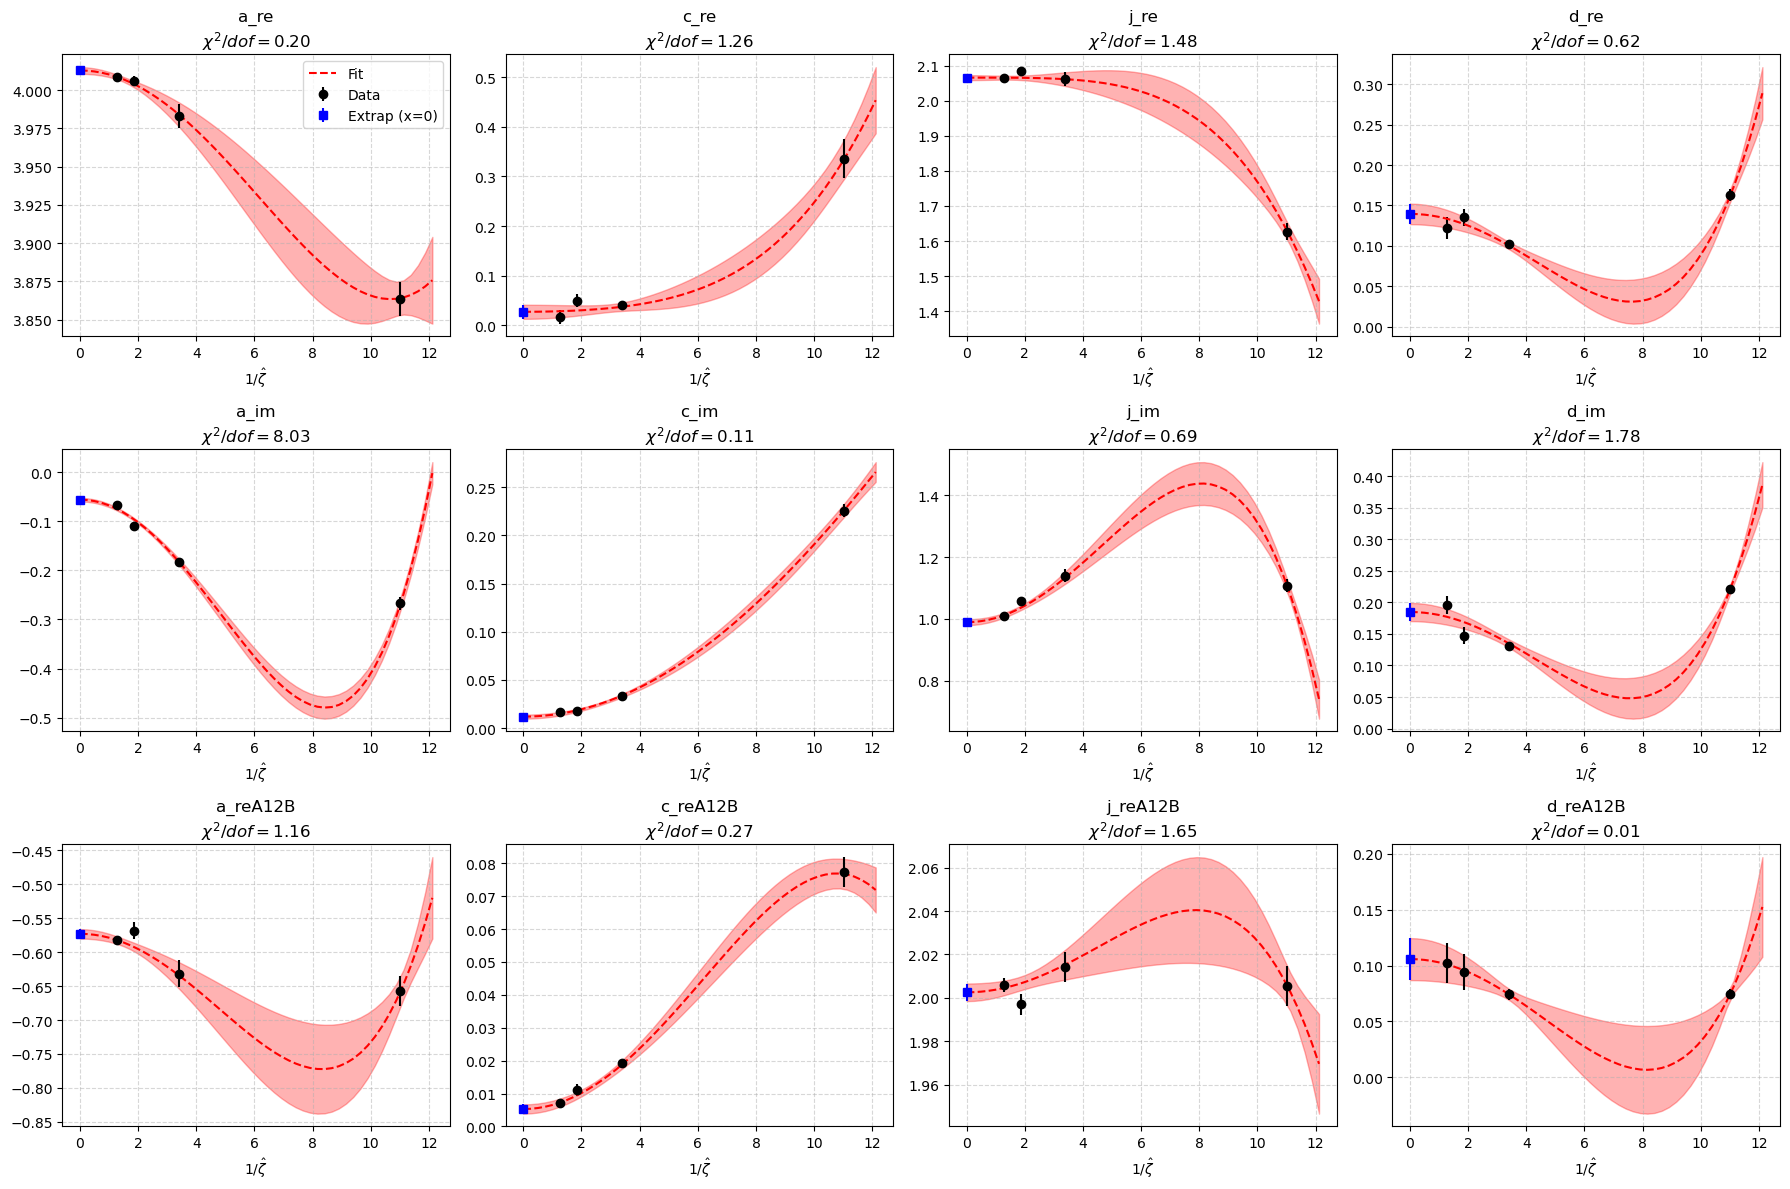

[3] Reconstructing Infinite-Momentum Amplitudes and Sivers Shift...


Evaluating x slices:   0%|          | 0/200 [00:00<?, ?it/s]

[4] Generating Final Plots...


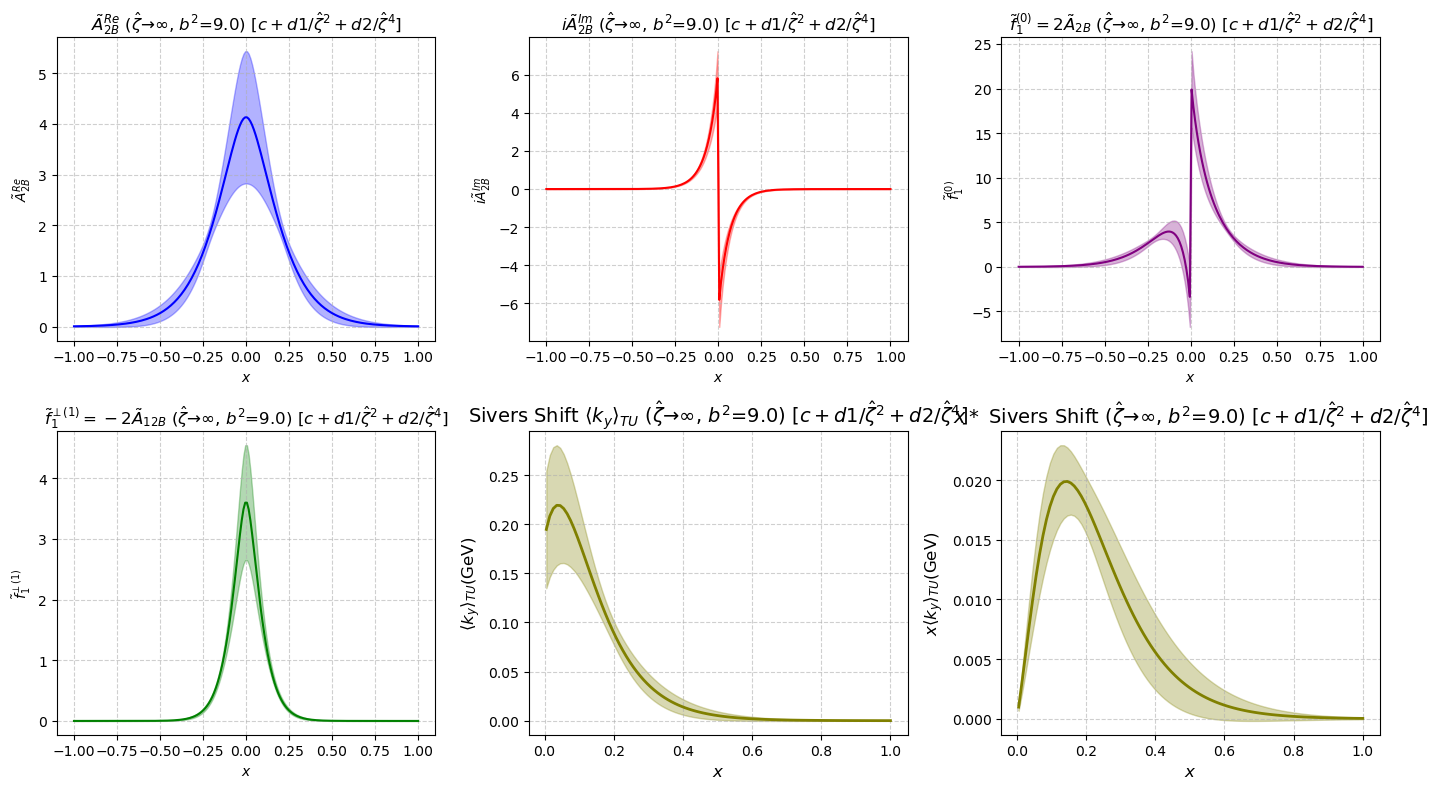

In [54]:
if __name__ == "__main__":
    PL_list = [-1, -2, -3, -4]
    
    bminfit = 3
    etamin = 6
    etamax = 10
    
    parameter_extrapolation_and_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=200)

[1] Loading and Scaling Parameters...
[2] Extrapolating Parameters to 1/zeta_hat -> 0...


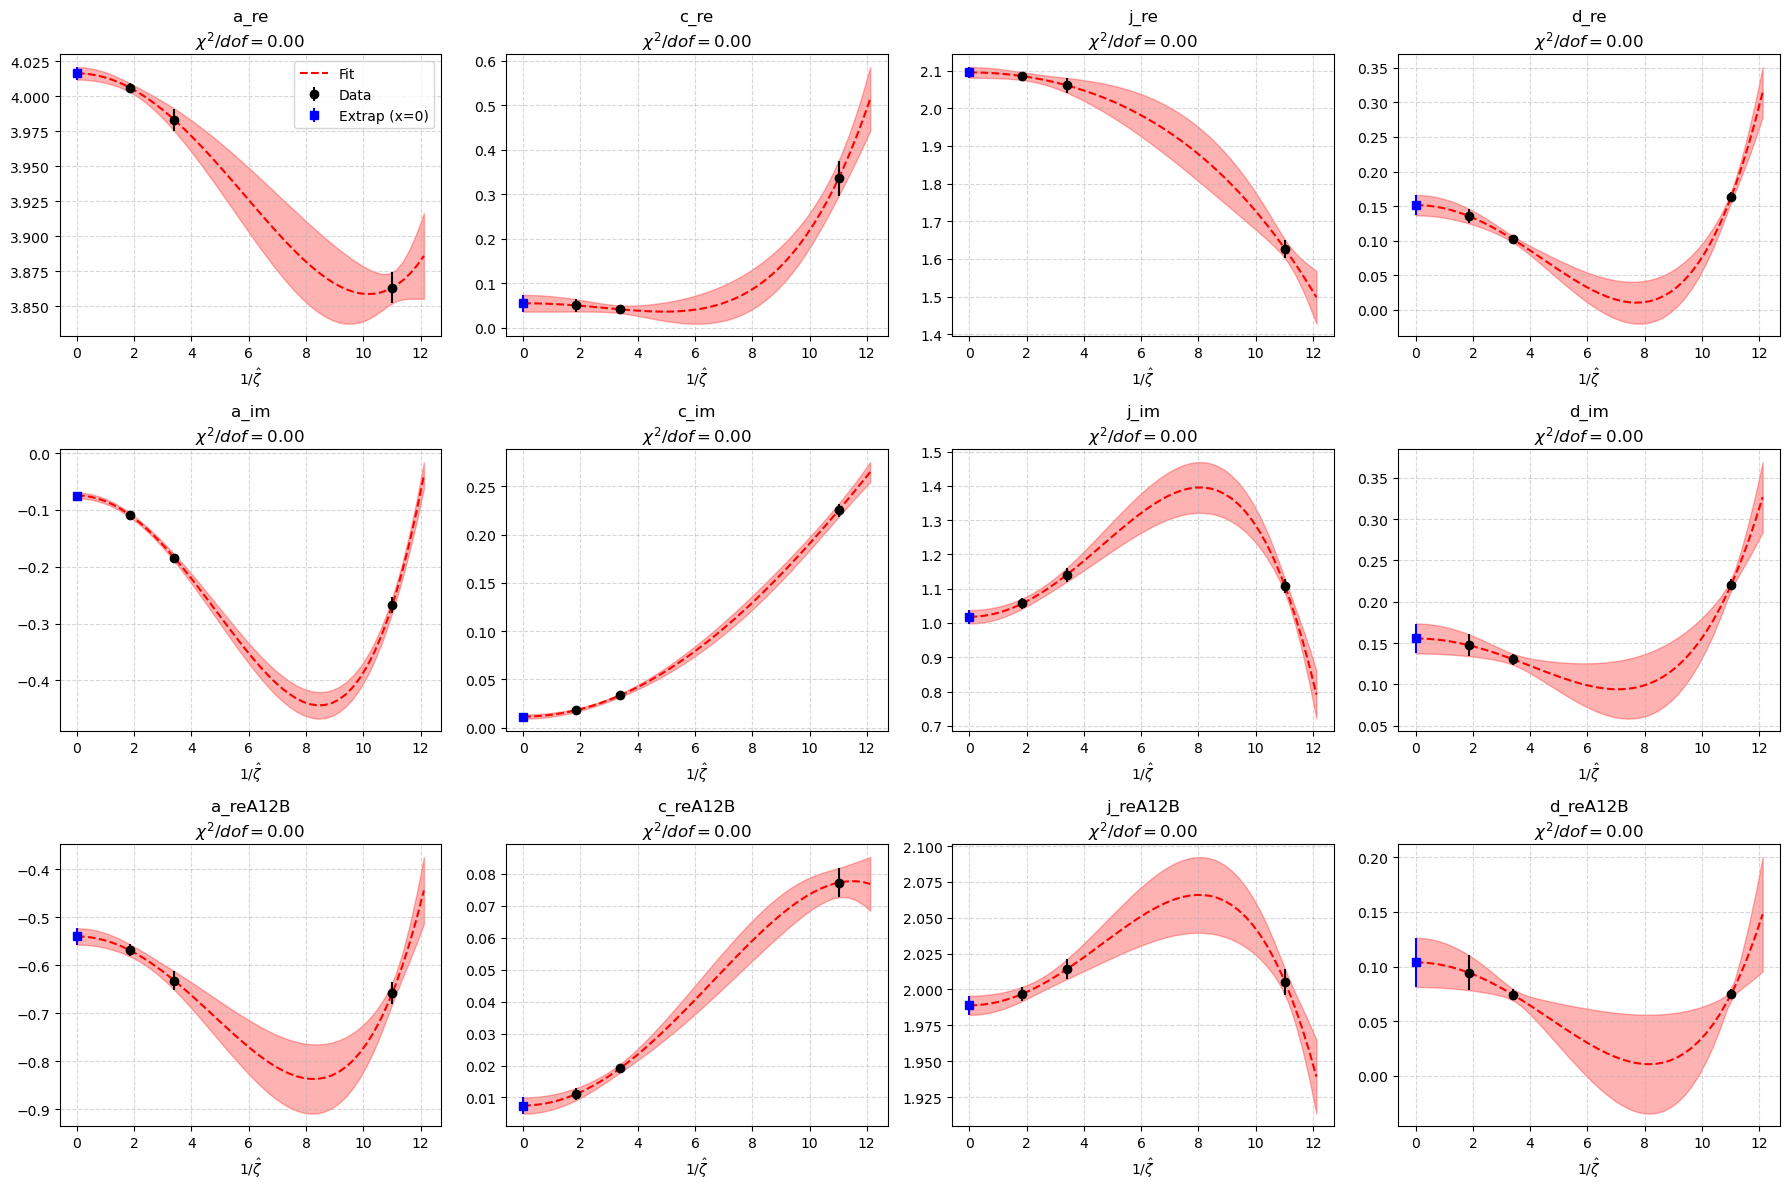

[3] Reconstructing Infinite-Momentum Amplitudes and Sivers Shift...


Evaluating x slices:   0%|          | 0/200 [00:00<?, ?it/s]

[4] Generating Final Plots...


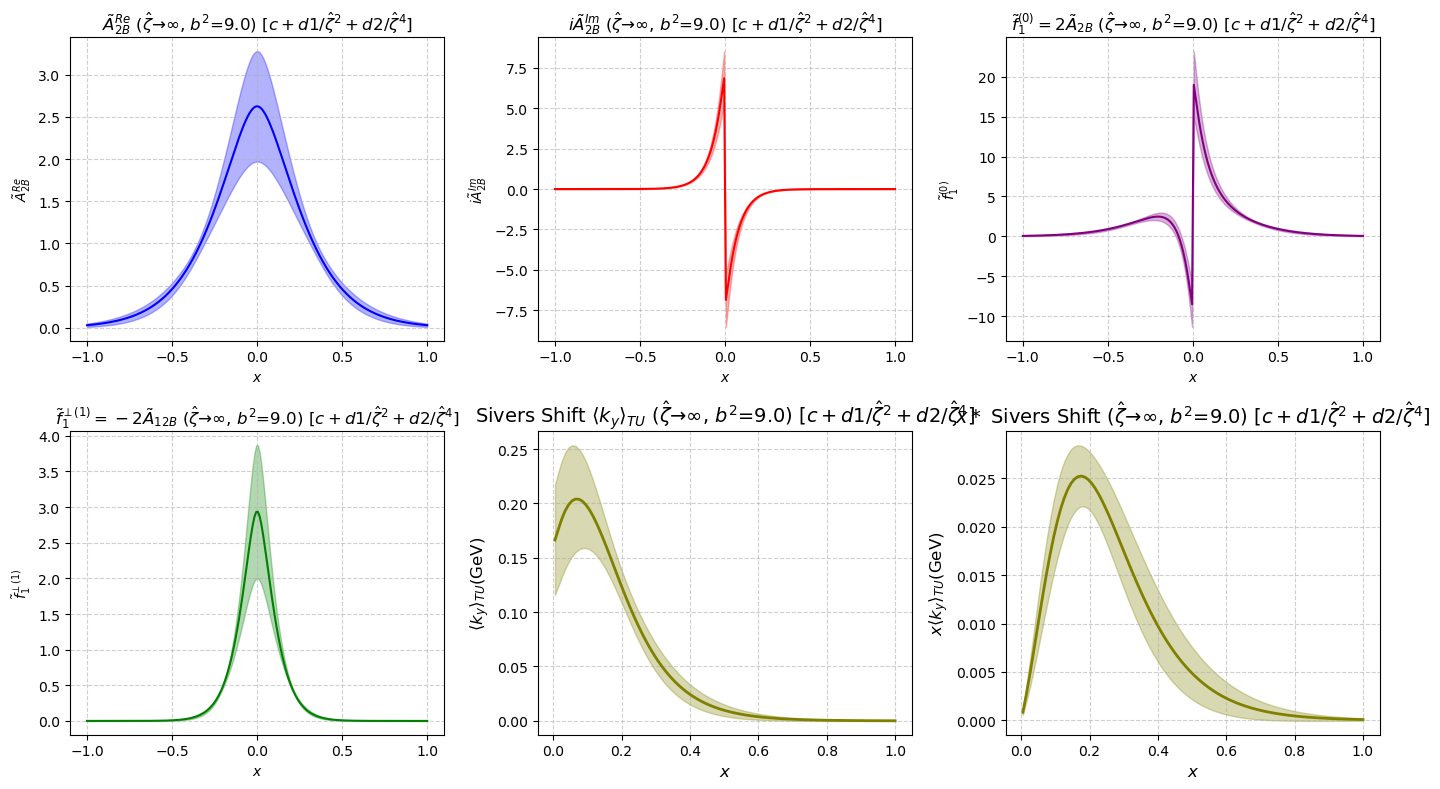

In [56]:
if __name__ == "__main__":
    PL_list = [-1, -2, -3]
    
    bminfit = 3
    etamin = 6
    etamax = 10
    
    parameter_extrapolation_and_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=200)

[1] Loading and Scaling Parameters...
[2] Extrapolating Parameters to 1/zeta_hat -> 0...


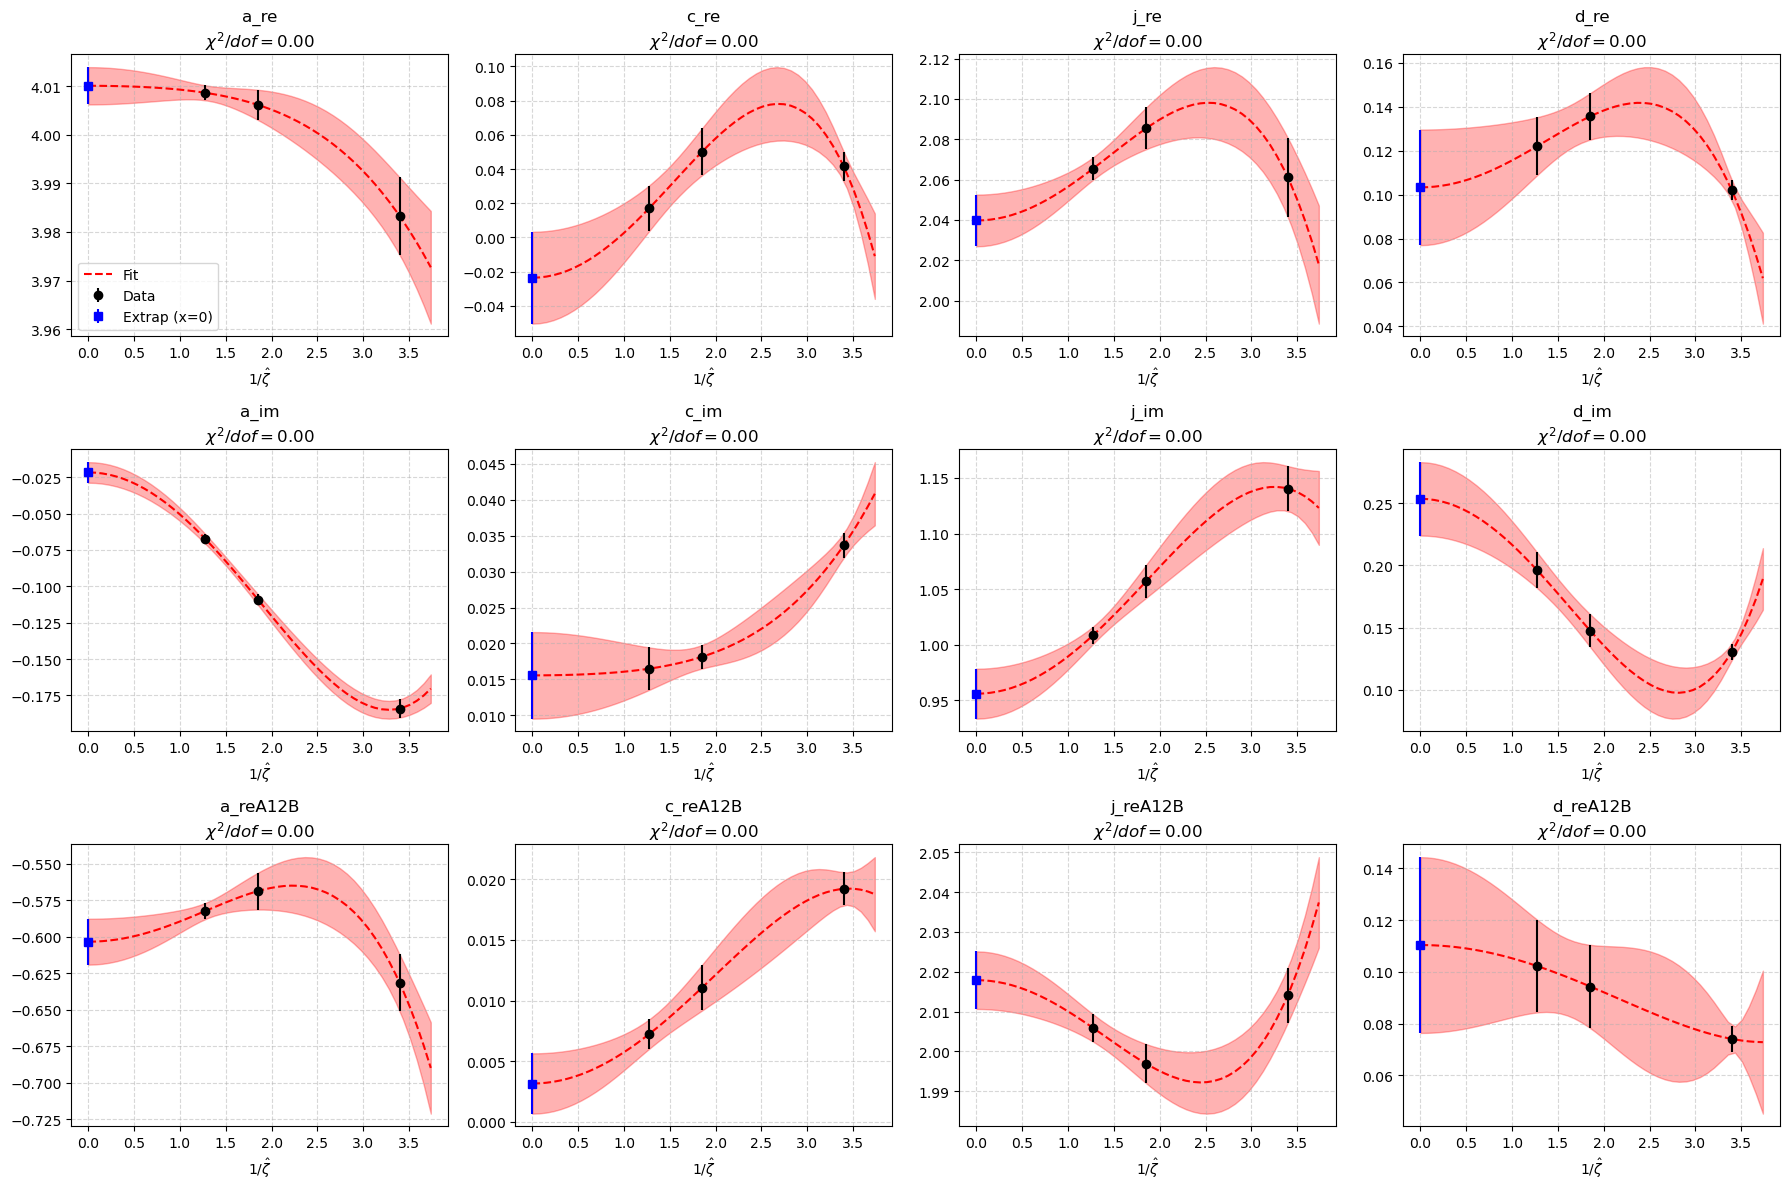

[3] Reconstructing Infinite-Momentum Amplitudes and Sivers Shift...


Evaluating x slices:   0%|          | 0/200 [00:00<?, ?it/s]

/var/folders/03/n3scp1nx27g50f8g9_zxcqjh0000gn/T/ipykernel_28859/2288849141.py:230: RuntimeWarning: invalid value encountered in scalar power
  term1_R = (2**(1 - j_R) * a_R * cd_R**(-0.25 - j_R/2) * d_R**(-j_R)) / gamma(j_R)
/var/folders/03/n3scp1nx27g50f8g9_zxcqjh0000gn/T/ipykernel_28859/2288849141.py:231: RuntimeWarning: invalid value encountered in sqrt
  re_eval = term1_R * (abs_x**(-0.5 + j_R)) * kv(0.5 - j_R, abs_x / np.sqrt(cd_R))


[4] Generating Final Plots...


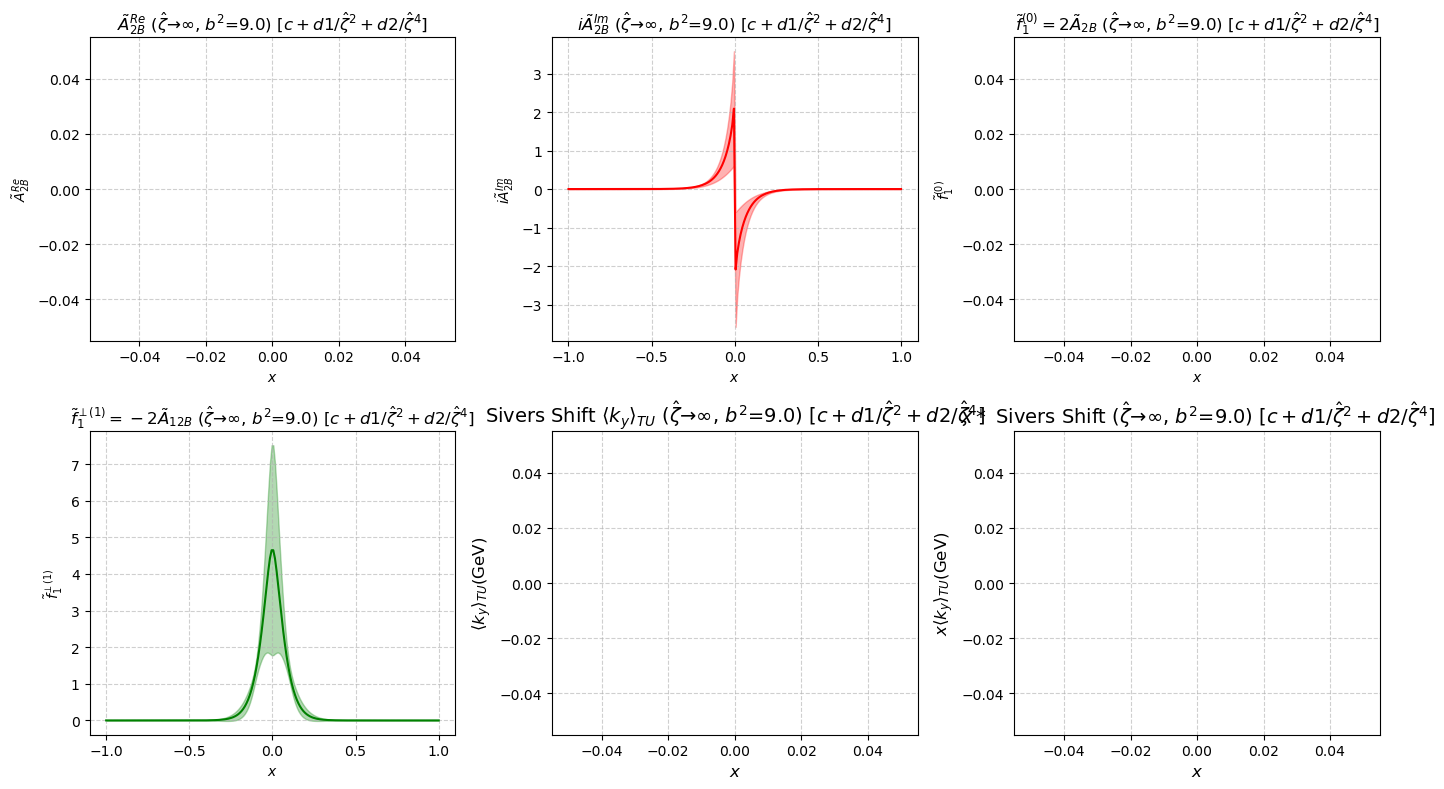

In [30]:
if __name__ == "__main__":
    PL_list = [-2, -3, -4]
    
    bminfit = 3
    etamin = 6
    etamax = 10
    
    parameter_extrapolation_and_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=200)

In [60]:
import h5py
import numpy as np
import math
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma

# ---------------------------------------------------------
# 1. Helpers & Statistics
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    if err <= 0: return f"{mean}"
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
    else:
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1)) 
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"

def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
    return fitted_params

# ---------------------------------------------------------
# 2. Extrapolation Routine for Parameters
# ---------------------------------------------------------
def fit_param_linear(inv_zeta_vals, param_jk_samples):
    """
    Fits y = c0 + c1 * (1/zeta_hat) for a given parameter.
    """
    N_PL, N_JK = param_jk_samples.shape

    mean_y = np.mean(param_jk_samples, axis=1)
    cov_y = np.cov(param_jk_samples, bias=True) * (N_JK - 1)

    try:
        y_gvar = gv.gvar(mean_y, cov_y)
    except Exception:
        y_gvar = gv.gvar(mean_y, np.sqrt(np.diag(cov_y)))

    # Linear fit in 1/zeta_hat
    def fcn(x, p):
        return p['c0'] + p['c1'] * x + p['c2'] * x**3

    prior = {'c0': gv.gvar(0, 5000000), 'c1': gv.gvar(0, 5000000), 'c2': gv.gvar(0, 5000000)}

    # Central fit for chi2/dof
    fit_mean = lsqfit.nonlinear_fit(data=(inv_zeta_vals, y_gvar), fcn=fcn, prior=prior)
    chi2_dof = fit_mean.chi2 / fit_mean.dof if fit_mean.dof > 0 else 0.0
    
    # Store central line for plotting
    c0_central = fit_mean.pmean['c0']
    c1_central = fit_mean.pmean['c1']
    c2_central = fit_mean.pmean['c2']

    # JK fits
    c0_jk = []
    c1_jk = []
    c2_jk = []
    cov_y_eval = gv.evalcov(y_gvar)

    for k in range(N_JK):
        y_k_gvar = gv.gvar(param_jk_samples[:, k], cov_y_eval)
        fit_k = lsqfit.nonlinear_fit(data=(inv_zeta_vals, y_k_gvar), fcn=fcn, prior=prior, svdcut=1e-4)
        c0_jk.append(fit_k.pmean['c0'])
        c1_jk.append(fit_k.pmean['c1'])
        c2_jk.append(fit_k.pmean['c2'])

    return np.array(c0_jk), np.array(c1_jk), np.array(c2_jk), chi2_dof, c0_central, c1_central, c2_central

# ---------------------------------------------------------
# 3. Main Routine
# ---------------------------------------------------------
def parameter_extrapolation_and_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=1000):
    
    MassN = 0.6228
    lata = 0.11403
    massterm = MassN * (197 * 0.001 / lata)
    
    pl_to_zeta = {
        -4: 0.785756,
        -3: 0.539684,
        -2: 0.294367,
        -1: 0.090772
    }
    
    inv_zeta_vals = np.array([1.0 / pl_to_zeta[pl] for pl in PL_list])
    sort_idx = np.argsort(inv_zeta_vals)
    inv_zeta_vals = inv_zeta_vals[sort_idx]
    sorted_PL_list = [PL_list[i] for i in sort_idx]
    N_PL = len(sorted_PL_list)
    
    # Create dynamic PL string for filenames (e.g. [-2, -3, -4] -> "234")
    pl_str = "".join([str(abs(p)) for p in sorted(PL_list, reverse=True)])
    
    # Load Initial Data to get N_JK
    init_filename = f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{sorted_PL_list[0]}.h5"
    init_params = load_params_from_h5(init_filename)
    N_JK = len(init_params['a_re'])

    # Dictionary to hold the scaled parameters for all PLs
    param_names = ['a_re', 'c_re', 'j_re', 'd_re', 
                   'a_im', 'c_im', 'j_im', 'd_im', 
                   'a_reA12B', 'c_reA12B', 'j_reA12B', 'd_reA12B']
                   
    raw_data = {p: np.zeros((N_PL, N_JK)) for p in param_names}

    print("[1] Loading and Scaling Parameters...")
    for i, pl in enumerate(sorted_PL_list):
        filename = f"/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/SimultaniousFit/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
        params = load_params_from_h5(filename)
        
        # Apply scaling rules
        raw_data['a_re'][i, :] = params['a_re']
        raw_data['c_re'][i, :] = params['c_re'] / (pl**2)
        raw_data['j_re'][i, :] = params['j_re']
        raw_data['d_re'][i, :] = params['d_re']
        
        raw_data['a_im'][i, :] = params['a_im'] / pl
        raw_data['c_im'][i, :] = params['c_im'] / (pl**2)
        raw_data['j_im'][i, :] = params['j_im']
        raw_data['d_im'][i, :] = params['d_im']
        
        raw_data['a_reA12B'][i, :] = -params['a_reA12B']
        raw_data['c_reA12B'][i, :] = params['c_reA12B'] / (pl**2)
        raw_data['j_reA12B'][i, :] = params['j_reA12B']
        raw_data['d_reA12B'][i, :] = params['d_reA12B']

    print("[2] Extrapolating Parameters to 1/zeta_hat -> 0...")
    extrapolated_jk = {}
    
    # Plotting setup for parameters
    fig_p, axes_p = plt.subplots(3, 4, figsize=(18, 12))
    axes_p = axes_p.flatten()
    plot_x = np.linspace(0, max(inv_zeta_vals)*1.1, 50)

    for idx, p_name in enumerate(param_names):
        jk_samples = raw_data[p_name]
        
        # Fit
        c0_jk, c1_jk, c2_jk, chi2, c0_cent, c1_cent, c2_cent = fit_param_linear(inv_zeta_vals, jk_samples)
        extrapolated_jk[p_name] = c0_jk
        
        # Get means and errors for the raw data points
        y_means = np.mean(jk_samples, axis=1)
        y_errs = [Jackknife(jk_samples[i, :])[1] for i in range(N_PL)]
        
        # Generate Error Band for the fit line
        fit_m = np.zeros(len(plot_x))
        fit_e = np.zeros(len(plot_x))
        for i_x, px in enumerate(plot_x):
            # Evaluate the linear fit at this x for all JK samples
            jk_vals_at_x = c0_jk + c1_jk * px + c2_jk * px**3
            fit_m[i_x], fit_e[i_x] = Jackknife(jk_vals_at_x)
        
        c0_m, c0_e = Jackknife(c0_jk)
        
        # Plot
        ax = axes_p[idx]
        ax.errorbar(inv_zeta_vals, y_means, yerr=y_errs, fmt='o', color='black', label='Data')
        ax.plot(plot_x, fit_m, color='red', linestyle='--', label='Fit')
        ax.fill_between(plot_x, fit_m - fit_e, fit_m + fit_e, color='red', alpha=0.3)
        ax.errorbar([0], [c0_m], yerr=[c0_e], fmt='s', color='blue', label='Extrap (x=0)')
        
        ax.set_title(f"{p_name}\n$\\chi^2/dof = {chi2:.2f}$")
        ax.set_xlabel("$1/\\hat{\\zeta}$")
        ax.grid(True, linestyle='--', alpha=0.5)
        if idx == 0: ax.legend()

    plt.tight_layout()
    plt.savefig(f"Param_Extrapolations_1byZetahat_1_1byZetahat_3_P{pl_str}_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf")
    plt.show()

    print("[3] Reconstructing Infinite-Momentum Amplitudes and Sivers Shift...")
    x_vals = np.linspace(-1, 1, num_points_x)
    
    # Pre-allocate arrays for all plot lines
    siv_m, siv_e = np.zeros(num_points_x), np.zeros(num_points_x)
    xsiv_m, xsiv_e = np.zeros(num_points_x), np.zeros(num_points_x)
    
    reA2B_m, reA2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    imA2B_m, imA2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    A2B_m, A2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    reA12B_m, reA12B_e = np.zeros(num_points_x), np.zeros(num_points_x)

    for j, x in enumerate(tqdm(x_vals, desc="Evaluating x slices")):
        abs_x = max(np.abs(x), 1e-12)
        safe_x = x if x != 0 else 1e-12
        
        # Slices to hold JK samples for this specific x
        siv_jk_slice = np.zeros(N_JK)
        reA2B_jk_slice = np.zeros(N_JK)
        imA2B_jk_slice = np.zeros(N_JK)
        A2B_jk_slice = np.zeros(N_JK)
        reA12B_jk_slice = np.zeros(N_JK)
        
        for k in range(N_JK):
            # Extract the extrapolated parameters for this specific JK sample
            a_R, c_R, d_R, j_R = extrapolated_jk['a_re'][k], extrapolated_jk['c_re'][k], 1.0 + extrapolated_jk['d_re'][k] * b2, extrapolated_jk['j_re'][k]
            a_I, c_I, d_I, j_I = extrapolated_jk['a_im'][k], extrapolated_jk['c_im'][k], 1.0 + extrapolated_jk['d_im'][k] * b2, extrapolated_jk['j_im'][k]
            a_A, c_A, d_A, j_A = extrapolated_jk['a_reA12B'][k], extrapolated_jk['c_reA12B'][k], 1.0 + extrapolated_jk['d_reA12B'][k] * b2, extrapolated_jk['j_reA12B'][k]

            # ReA2B
            cd_R = c_R / d_R # Safeguard
            term1_R = (2**(1 - j_R) * a_R * cd_R**(-0.25 - j_R/2) * d_R**(-j_R)) / gamma(j_R)
            re_eval = term1_R * (abs_x**(-0.5 + j_R)) * kv(0.5 - j_R, abs_x / np.sqrt(cd_R))

            # ImA2B
            cd_I = c_I / d_I # Safeguard
            term1_I = (2**(1 - j_I) * a_I * cd_I**(0.25 * (-3 - 2*j_I)) * d_I**(-j_I)) / gamma(j_I)
            im_eval = term1_I * (safe_x * abs_x**(-1.5 + j_I)) * kv(1.5 - j_I, np.sqrt(d_I / c_I) * abs_x)

            # ReA12B
            cd_A = c_A / d_A # Safeguard
            term1_A = (2**(1 - j_A) * a_A * cd_A**(-0.25 - j_A/2) * d_A**(-j_A)) / gamma(j_A)
            reA12B_eval = term1_A * (abs_x**(-0.5 + j_A)) * kv(0.5 - j_A, abs_x / np.sqrt(cd_A))

            # Store exact values into JK slices
            reA2B_jk_slice[k] = re_eval
            imA2B_jk_slice[k] = im_eval
            reA12B_jk_slice[k] = -2*reA12B_eval
            A2B_jk_slice[k] = 2*(re_eval - im_eval)
            siv_jk_slice[k] = (-massterm * reA12B_eval) / (re_eval - im_eval)

        # Jackknife the final reconstructed arrays to get standard means and errors
        siv_m[j], siv_e[j] = Jackknife(siv_jk_slice)
        xsiv_m[j], xsiv_e[j] = Jackknife(x * siv_jk_slice)
        
        reA2B_m[j], reA2B_e[j] = Jackknife(reA2B_jk_slice)
        imA2B_m[j], imA2B_e[j] = Jackknife(imA2B_jk_slice)
        reA12B_m[j], reA12B_e[j] = Jackknife(reA12B_jk_slice)
        A2B_m[j], A2B_e[j] = Jackknife(A2B_jk_slice)

    # ---------------------------------------------------------
    # 4. Final Plotting (6 Panel Layout)
    # ---------------------------------------------------------
    print("[4] Generating Final Plots...")
    fig_s, axes_s = plt.subplots(2, 3, figsize=(14, 8))
    ax1, ax2, ax3, ax4, ax5, ax6 = axes_s.flatten()

    # Real Plot
    ax1.plot(x_vals, reA2B_m, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, reA2B_m - reA2B_e, reA2B_m + reA2B_e, color='blue', alpha=0.3)
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d1/\\hat{{\\zeta}}+d2/\\hat{{\\zeta}}^3$]')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, imA2B_m, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, imA2B_m - imA2B_e, imA2B_m + imA2B_e, color='red', alpha=0.3) 
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d1/\\hat{{\\zeta}}+d2/\\hat{{\\zeta}}^3$]')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Full f1 Plot
    ax3.plot(x_vals, A2B_m, color='purple', label='A2B Mean')
    ax3.fill_between(x_vals, A2B_m - A2B_e, A2B_m + A2B_e, color='purple', alpha=0.3)
    ax3.set_title(f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d1/\\hat{{\\zeta}}+d2/\\hat{{\\zeta}}^3$]')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{f}}_{{1}}^{{(0)}}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    # A12B Plot
    ax4.plot(x_vals, reA12B_m, color='green')
    ax4.fill_between(x_vals, reA12B_m - reA12B_e, reA12B_m + reA12B_e, color='green', alpha=0.3)
    ax4.set_title(f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d1/\\hat{{\\zeta}}+d2/\\hat{{\\zeta}}^3$]')
    ax4.set_xlabel('$x$')
    ax4.set_ylabel('$\\tilde{{f}}_{{1}}^{{\\perp(1)}}$')
    ax4.grid(True, linestyle='--', alpha=0.6)

    # Sivers Shift Plot
    mask = x_vals >= 0
    ax5.plot(x_vals[mask], siv_m[mask], color='olive', linewidth=2)
    ax5.fill_between(x_vals[mask], siv_m[mask] - siv_e[mask], siv_m[mask] + siv_e[mask], color='olive', alpha=0.3)
    ax5.set_title(f'Sivers Shift $\\langle k_{{y}} \\rangle_{{TU}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d1/\\hat{{\\zeta}}+d2/\\hat{{\\zeta}}^3$]', fontsize=14)
    ax5.set_xlabel('$x$', fontsize=12)
    ax5.set_ylabel('$\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    ax5.grid(True, linestyle='--', alpha=0.6)

    # x * Sivers Shift Plot
    ax6.plot(x_vals[mask], xsiv_m[mask], color='olive', linewidth=2)
    ax6.fill_between(x_vals[mask], xsiv_m[mask] - xsiv_e[mask], xsiv_m[mask] + xsiv_e[mask], color='olive', alpha=0.3)
    ax6.set_title(f'$x *$ Sivers Shift ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d1/\\hat{{\\zeta}}+d2/\\hat{{\\zeta}}^3$]', fontsize=14)
    ax6.set_xlabel('$x$', fontsize=12)
    ax6.set_ylabel('$x\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    ax6.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    file_name = f"Extrapolated_AmpLevel_P{pl_str}_Sivers_1_over_zetahat_1_1_over_zetahat_3_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()



[1] Loading and Scaling Parameters...
[2] Extrapolating Parameters to 1/zeta_hat -> 0...


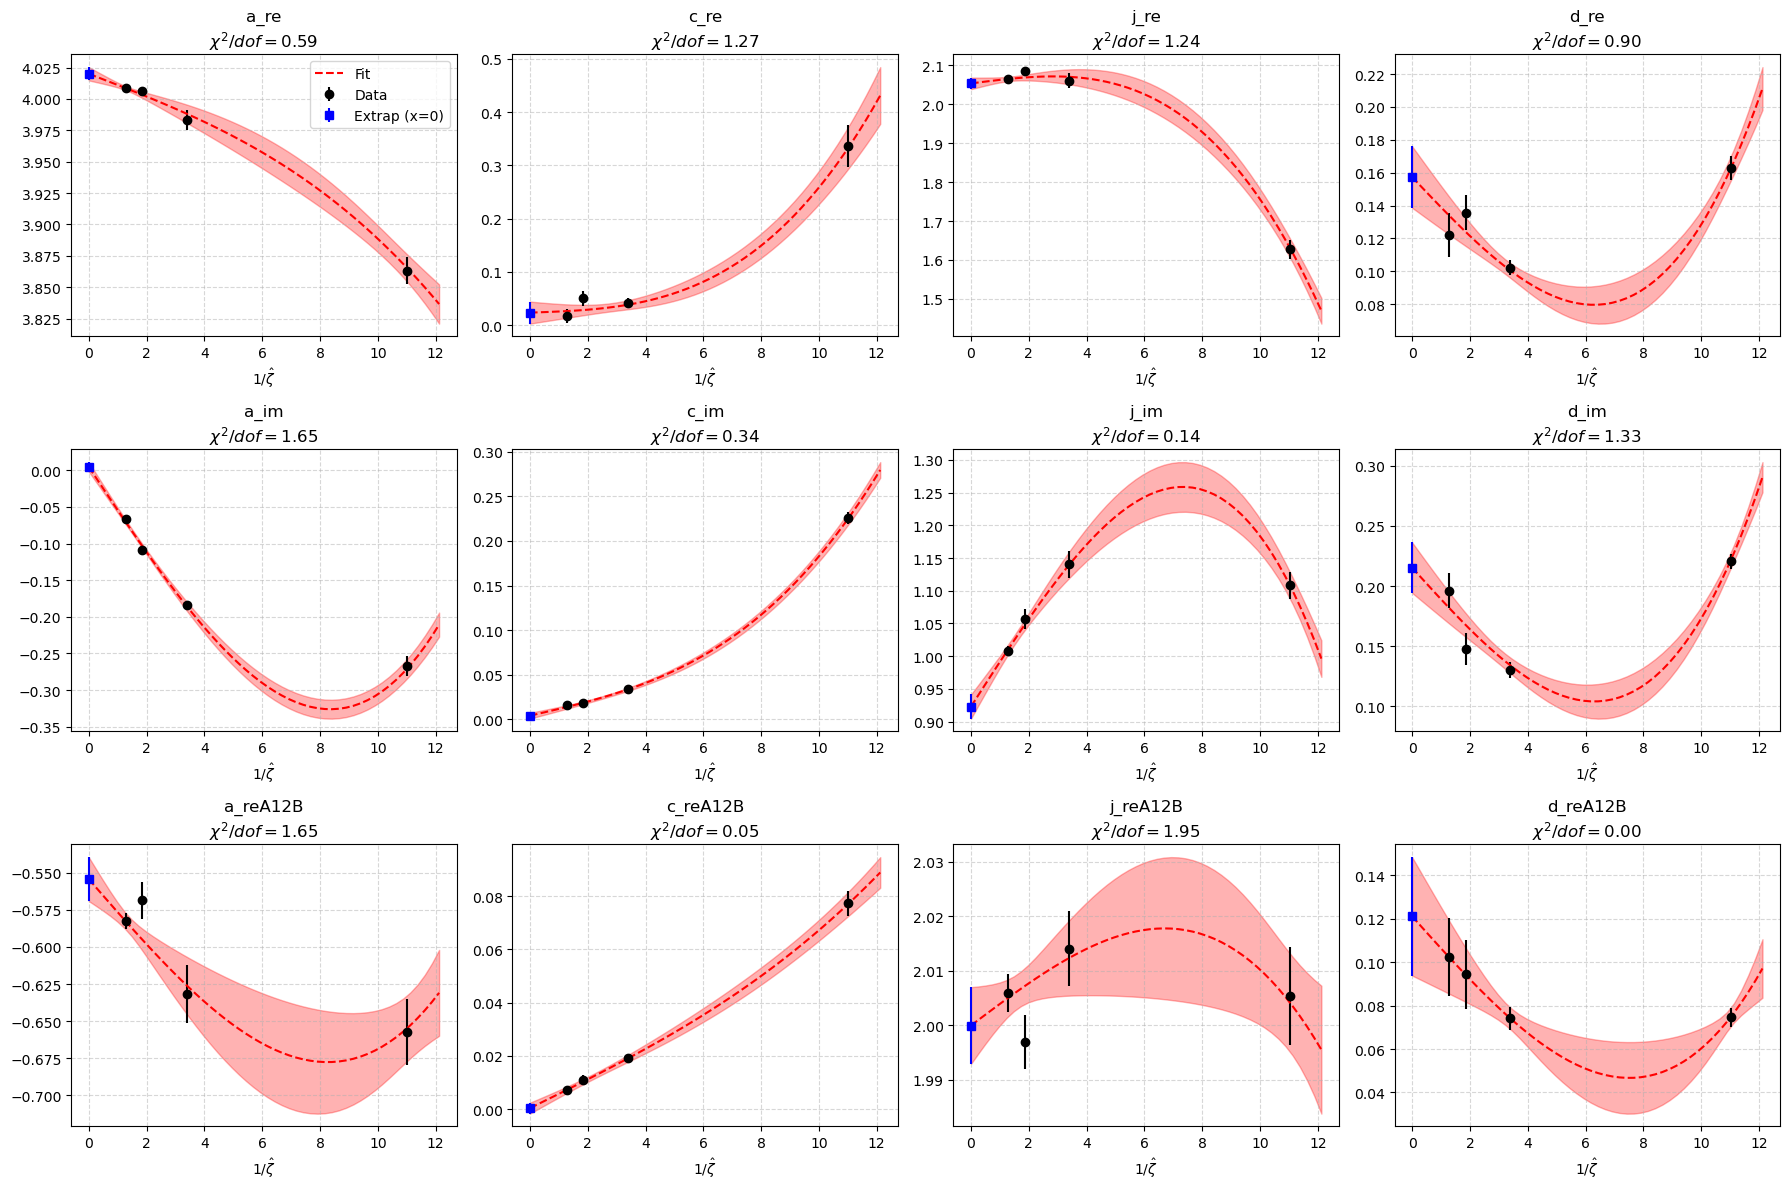

[3] Reconstructing Infinite-Momentum Amplitudes and Sivers Shift...


Evaluating x slices:   0%|          | 0/200 [00:00<?, ?it/s]

[4] Generating Final Plots...


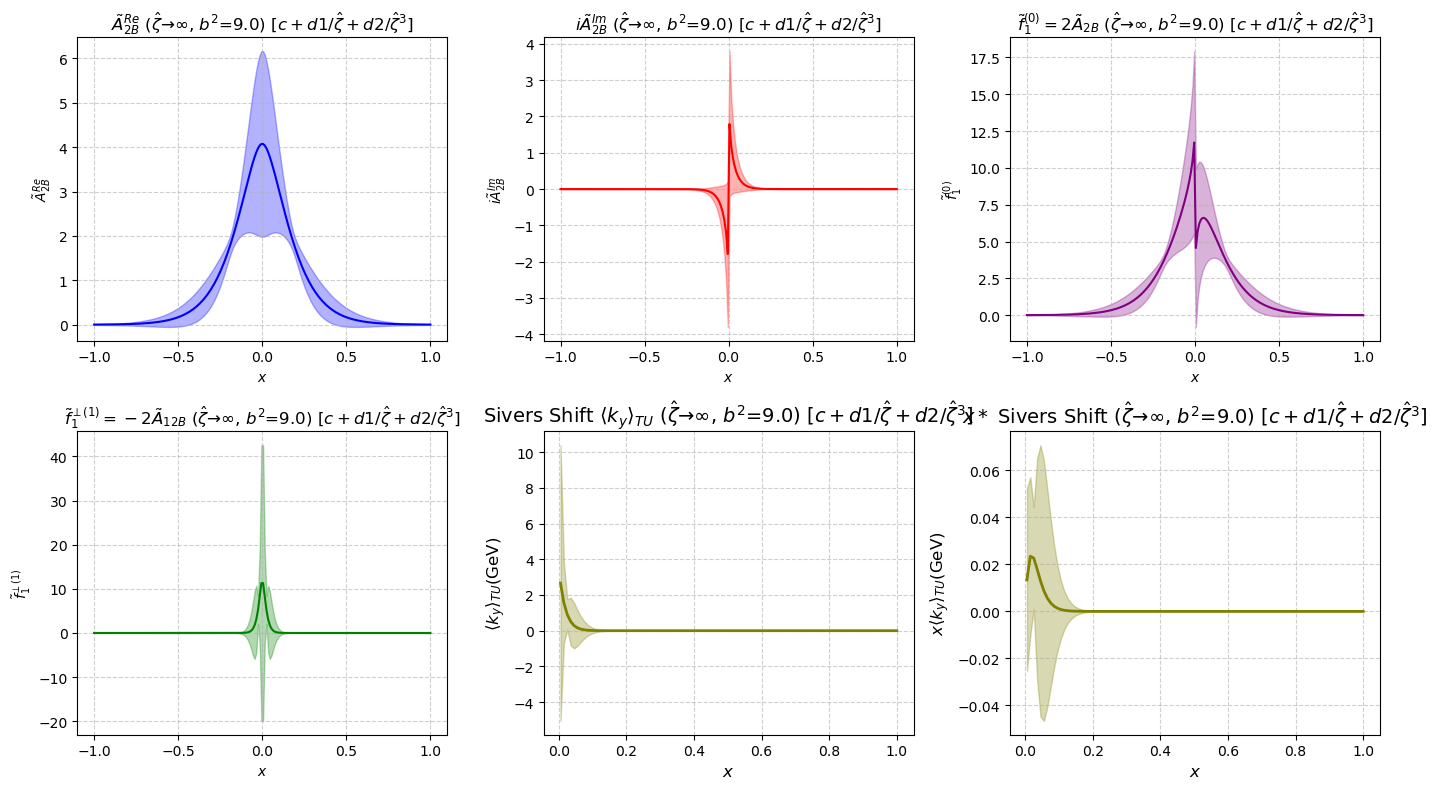

In [38]:
if __name__ == "__main__":
    PL_list = [-1, -2, -3, -4]
    
    bminfit = 3
    etamin = 6
    etamax = 10
    
    parameter_extrapolation_and_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=200)

[1] Loading and Scaling Parameters...
[2] Extrapolating Parameters to 1/zeta_hat -> 0...


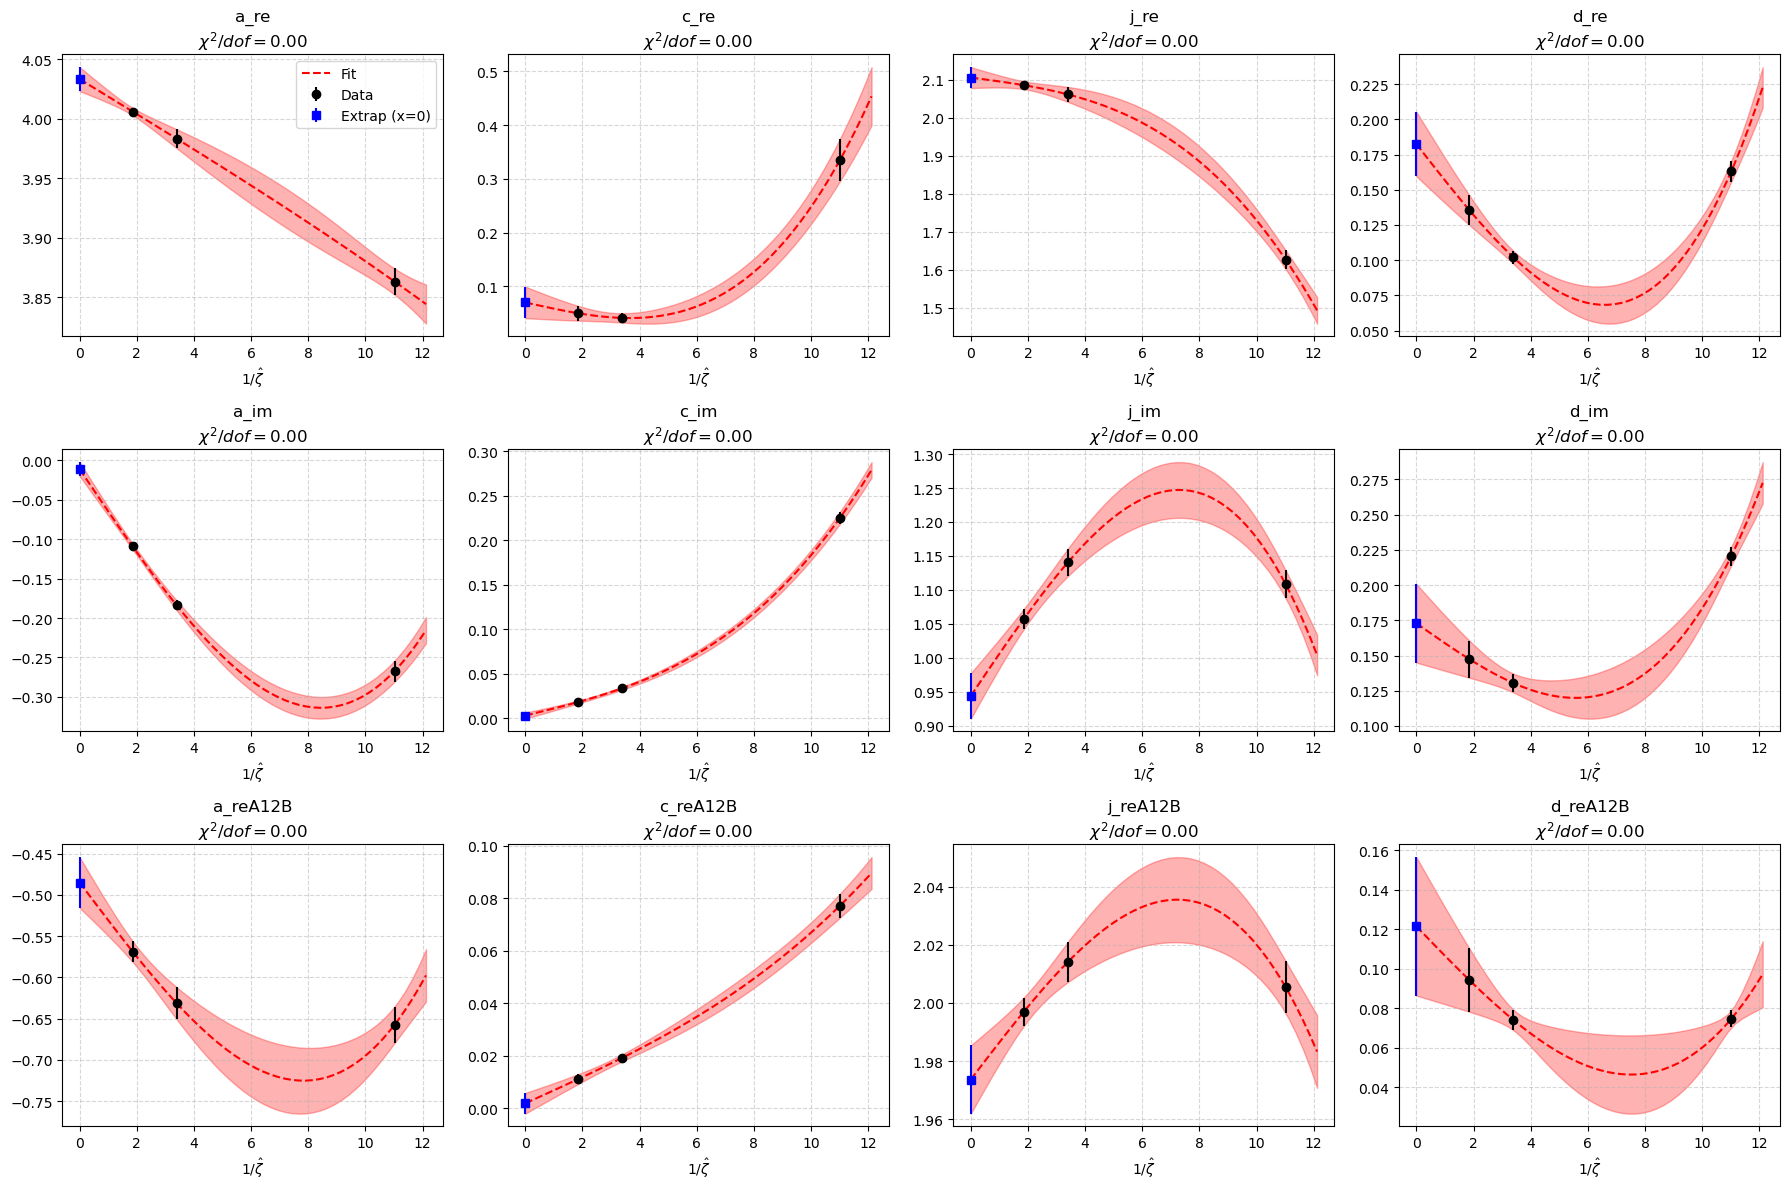

[3] Reconstructing Infinite-Momentum Amplitudes and Sivers Shift...


Evaluating x slices:   0%|          | 0/200 [00:00<?, ?it/s]

[4] Generating Final Plots...


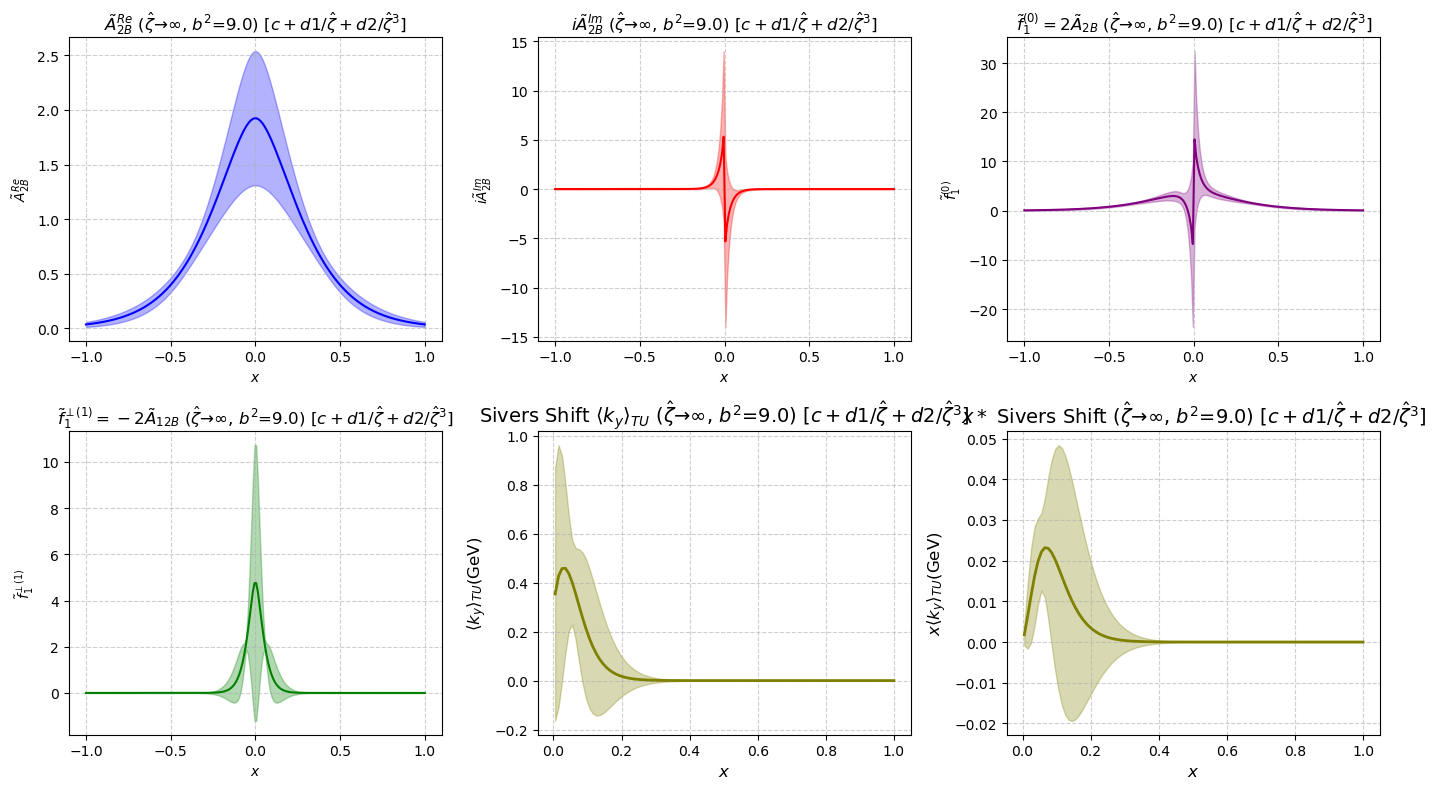

In [62]:
if __name__ == "__main__":
    PL_list = [-1, -2, -3]
    
    bminfit = 3
    etamin = 6
    etamax = 10
    
    parameter_extrapolation_and_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=200)

[1] Loading and Scaling Parameters...
[2] Extrapolating Parameters to 1/zeta_hat -> 0...


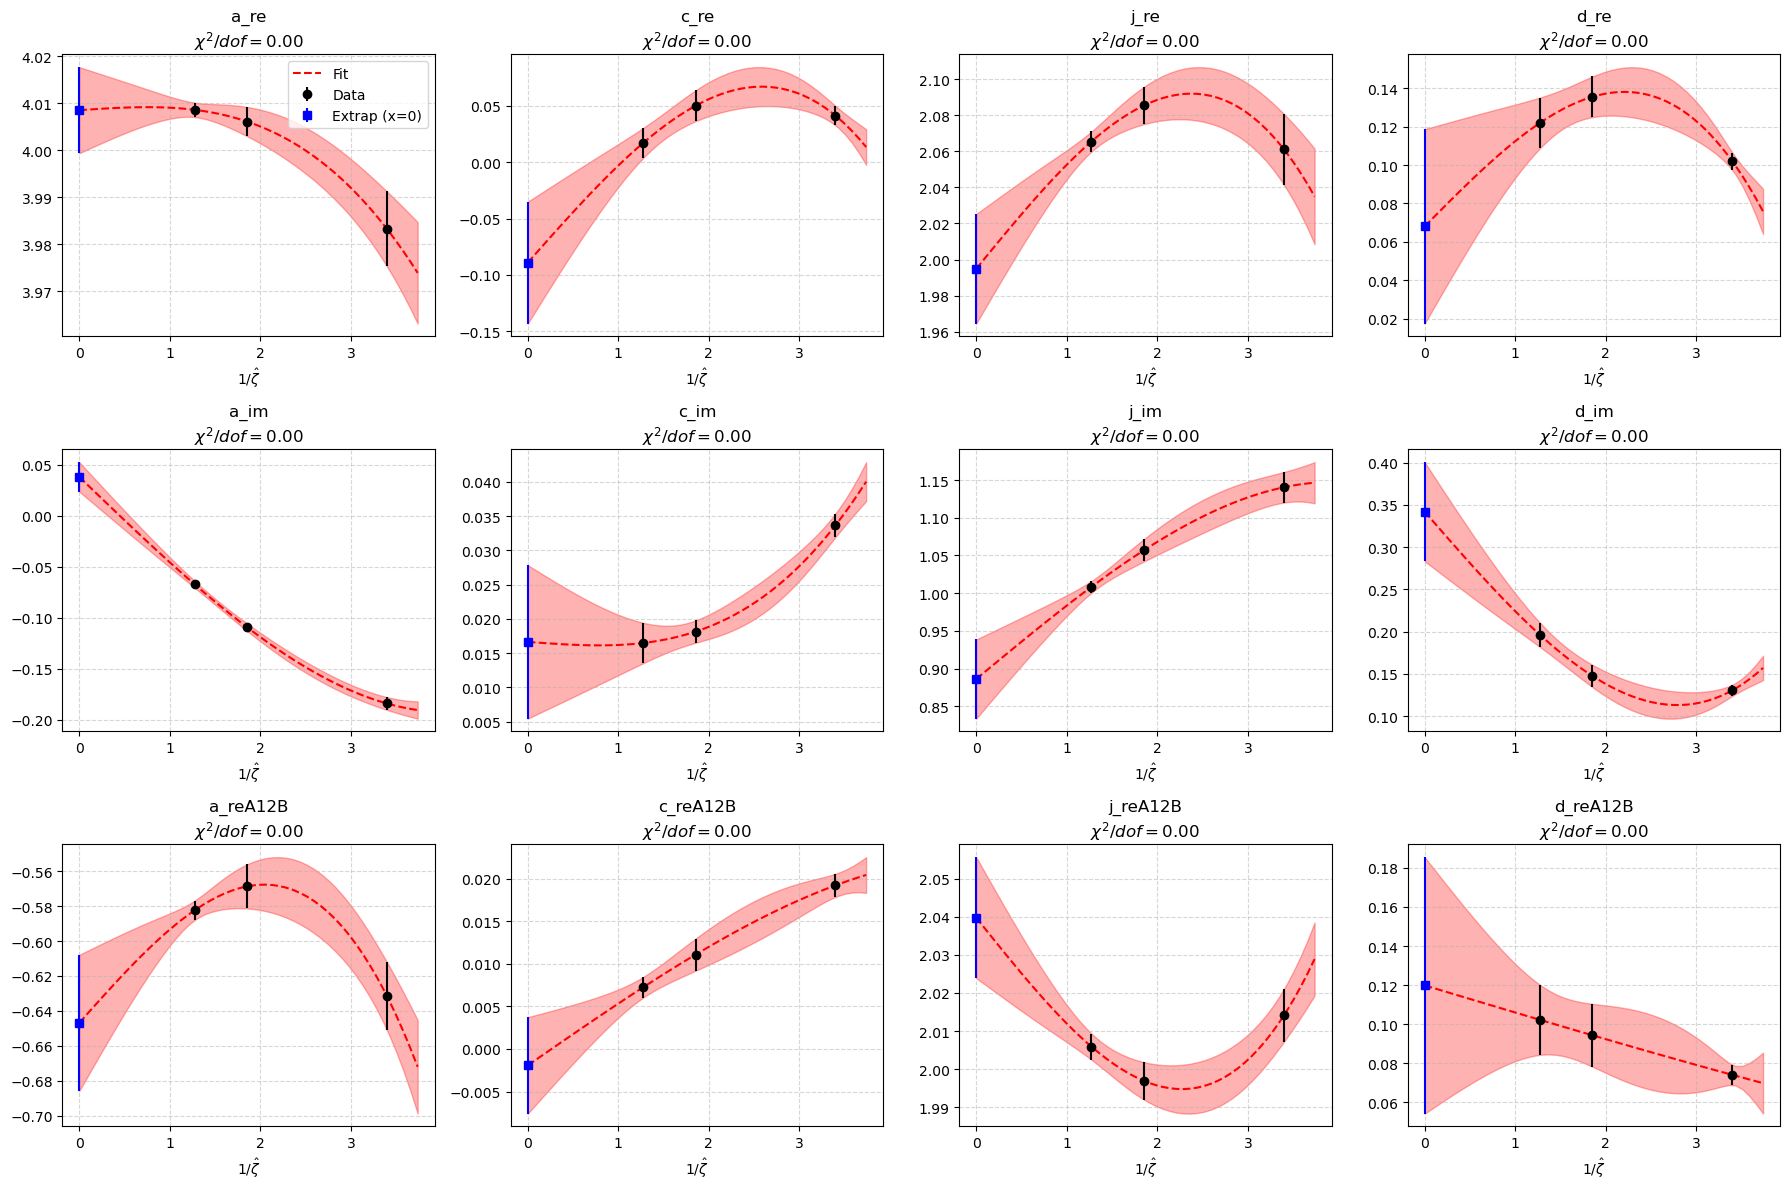

[3] Reconstructing Infinite-Momentum Amplitudes and Sivers Shift...


Evaluating x slices:   0%|          | 0/200 [00:00<?, ?it/s]

/var/folders/03/n3scp1nx27g50f8g9_zxcqjh0000gn/T/ipykernel_28859/3579090869.py:230: RuntimeWarning: invalid value encountered in scalar power
  term1_R = (2**(1 - j_R) * a_R * cd_R**(-0.25 - j_R/2) * d_R**(-j_R)) / gamma(j_R)
/var/folders/03/n3scp1nx27g50f8g9_zxcqjh0000gn/T/ipykernel_28859/3579090869.py:231: RuntimeWarning: invalid value encountered in sqrt
  re_eval = term1_R * (abs_x**(-0.5 + j_R)) * kv(0.5 - j_R, abs_x / np.sqrt(cd_R))
/var/folders/03/n3scp1nx27g50f8g9_zxcqjh0000gn/T/ipykernel_28859/3579090869.py:240: RuntimeWarning: invalid value encountered in scalar power
  term1_A = (2**(1 - j_A) * a_A * cd_A**(-0.25 - j_A/2) * d_A**(-j_A)) / gamma(j_A)
/var/folders/03/n3scp1nx27g50f8g9_zxcqjh0000gn/T/ipykernel_28859/3579090869.py:241: RuntimeWarning: invalid value encountered in sqrt
  reA12B_eval = term1_A * (abs_x**(-0.5 + j_A)) * kv(0.5 - j_A, abs_x / np.sqrt(cd_A))


[4] Generating Final Plots...


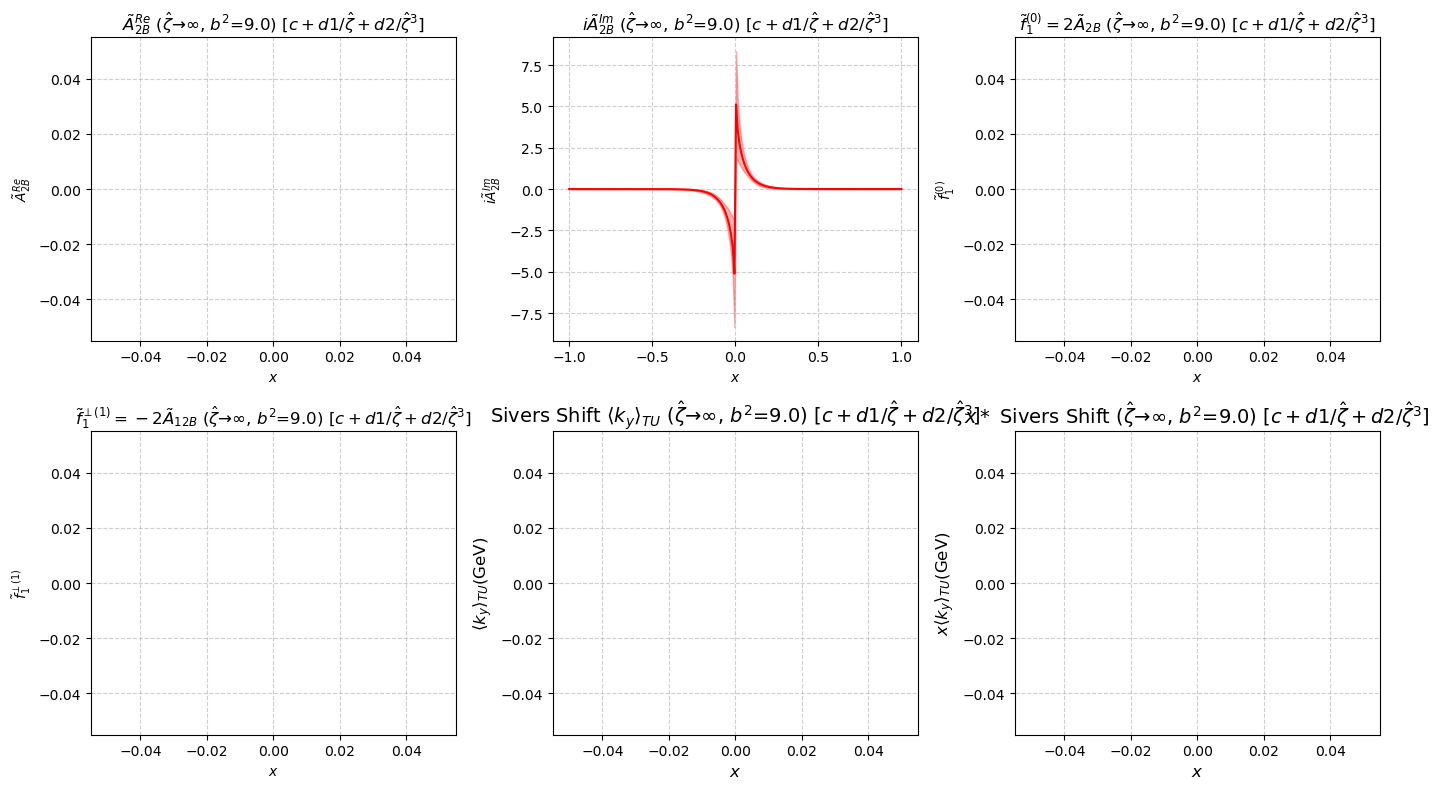

In [40]:
if __name__ == "__main__":
    PL_list = [-2, -3, -4]
    
    bminfit = 3
    etamin = 6
    etamax = 10
    
    parameter_extrapolation_and_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=200)